In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import anndata as ad

import warnings

  
warnings.simplefilter("ignore", category=UserWarning)

warnings.simplefilter("ignore", category=FutureWarning)  

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "fig1"


In [3]:
#adata=sc.read_h5ad('/nfs/team298/ls34/new_disease_atlas/model_XENIUMLABELT_final_scrna_paper_1917/adata_all_scvi7.h5ad.countsonly.clustered_leidenres1')
#adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna.clean')
PATH='/nfs/team298/ls34/adult_skin/final_adatas/adata_scrna_webportal.h5ad'
adata=sc.read_h5ad(PATH)
adata.shape



(1730938, 32732)

In [4]:
adata.obs.dataset_id.value_counts()

dataset_id
Reynolds                      270768
Fiskin_AD                     258665
Luc_Psoriasis                 200265
Ganier_BCC                    150893
Ahlers_Dermalsheath            94951
Ma_Psoriasis                   84340
Church_Healthy                 74402
bullous_pemphigoid             53824
Rojahn_AD                      49822
Dunlap_Lupus                   49821
Direder_Keloid                 47256
Greenleaf_AA                   41131
Ji_SCCarcinoma                 34340
Sole-Boldo                     27273
Kersh_Lichen planus            22686
Tabib_SSc                      22486
Ma_SSc                         21283
Ma_Prurigo                     20892
Dobie_Dupuytren                20052
LocalSSc_Hutchins              18152
Weidmann_Healthy               17922
Jiang_Lyme                     17215
Kim_DRESS                      14655
Bangert_AD                     14493
Deng_Keloid                    11777
Shiu_VitiligoBlister           11513
Moran_HS                   

In [5]:
adata.obs.dataset_id.nunique()

37

In [6]:
sorted(adata.obs.dataset_id.unique())

['Ahlers_Dermalsheath',
 'Bangert_AD',
 'Church_Healthy',
 'Damo_ImmunotherapyReaction',
 'Deng_Keloid',
 'Direder_Keloid',
 'Dobie_Dupuytren',
 'Dunlap_Lupus',
 'Fiskin_AD',
 'Ganier_BCC',
 'Greenleaf_AA',
 'Ji_SCCarcinoma',
 'Jiang_Lyme',
 'Kersh_Lichen planus',
 'Kim_DRESS',
 'Lee_AA_NY',
 'LocalSSc_Hutchins',
 'Luc_Psoriasis',
 'Ma_Prurigo',
 'Ma_Psoriasis',
 'Ma_SSc',
 'Mariottoni_HS',
 'Moran_HS',
 'Ning_Wound',
 'Reynolds',
 'Rojahn_AD',
 'Shiu_VitiligoBlister',
 'Sole-Boldo',
 'Tabib_SSc',
 'Takahashi',
 'Th2Stroma_Boothby',
 'Wang_GA',
 'Weidmann_Healthy',
 'Xing_PSMorphoea',
 'Yu_HS_NY',
 'bullous_pemphigoid',
 'prurigo_calugura_GSE213849']

In [7]:
import pickle

file_path = '/nfs/team298/ls34/color_for_adult_skin2.pkl'

# Load the dict back
with open(file_path, 'rb') as file:
    colors = pickle.load(file)

# Now colors is available
adata.obs['lvl5_annotation'] = adata.obs['lvl5_annotation'].astype('category')
adata.uns['lvl5_annotation_colors'] = [
    colors.get(cat, '#D3D3D3')  # Default to light grey if not found
    for cat in adata.obs['lvl5_annotation'].cat.categories
]

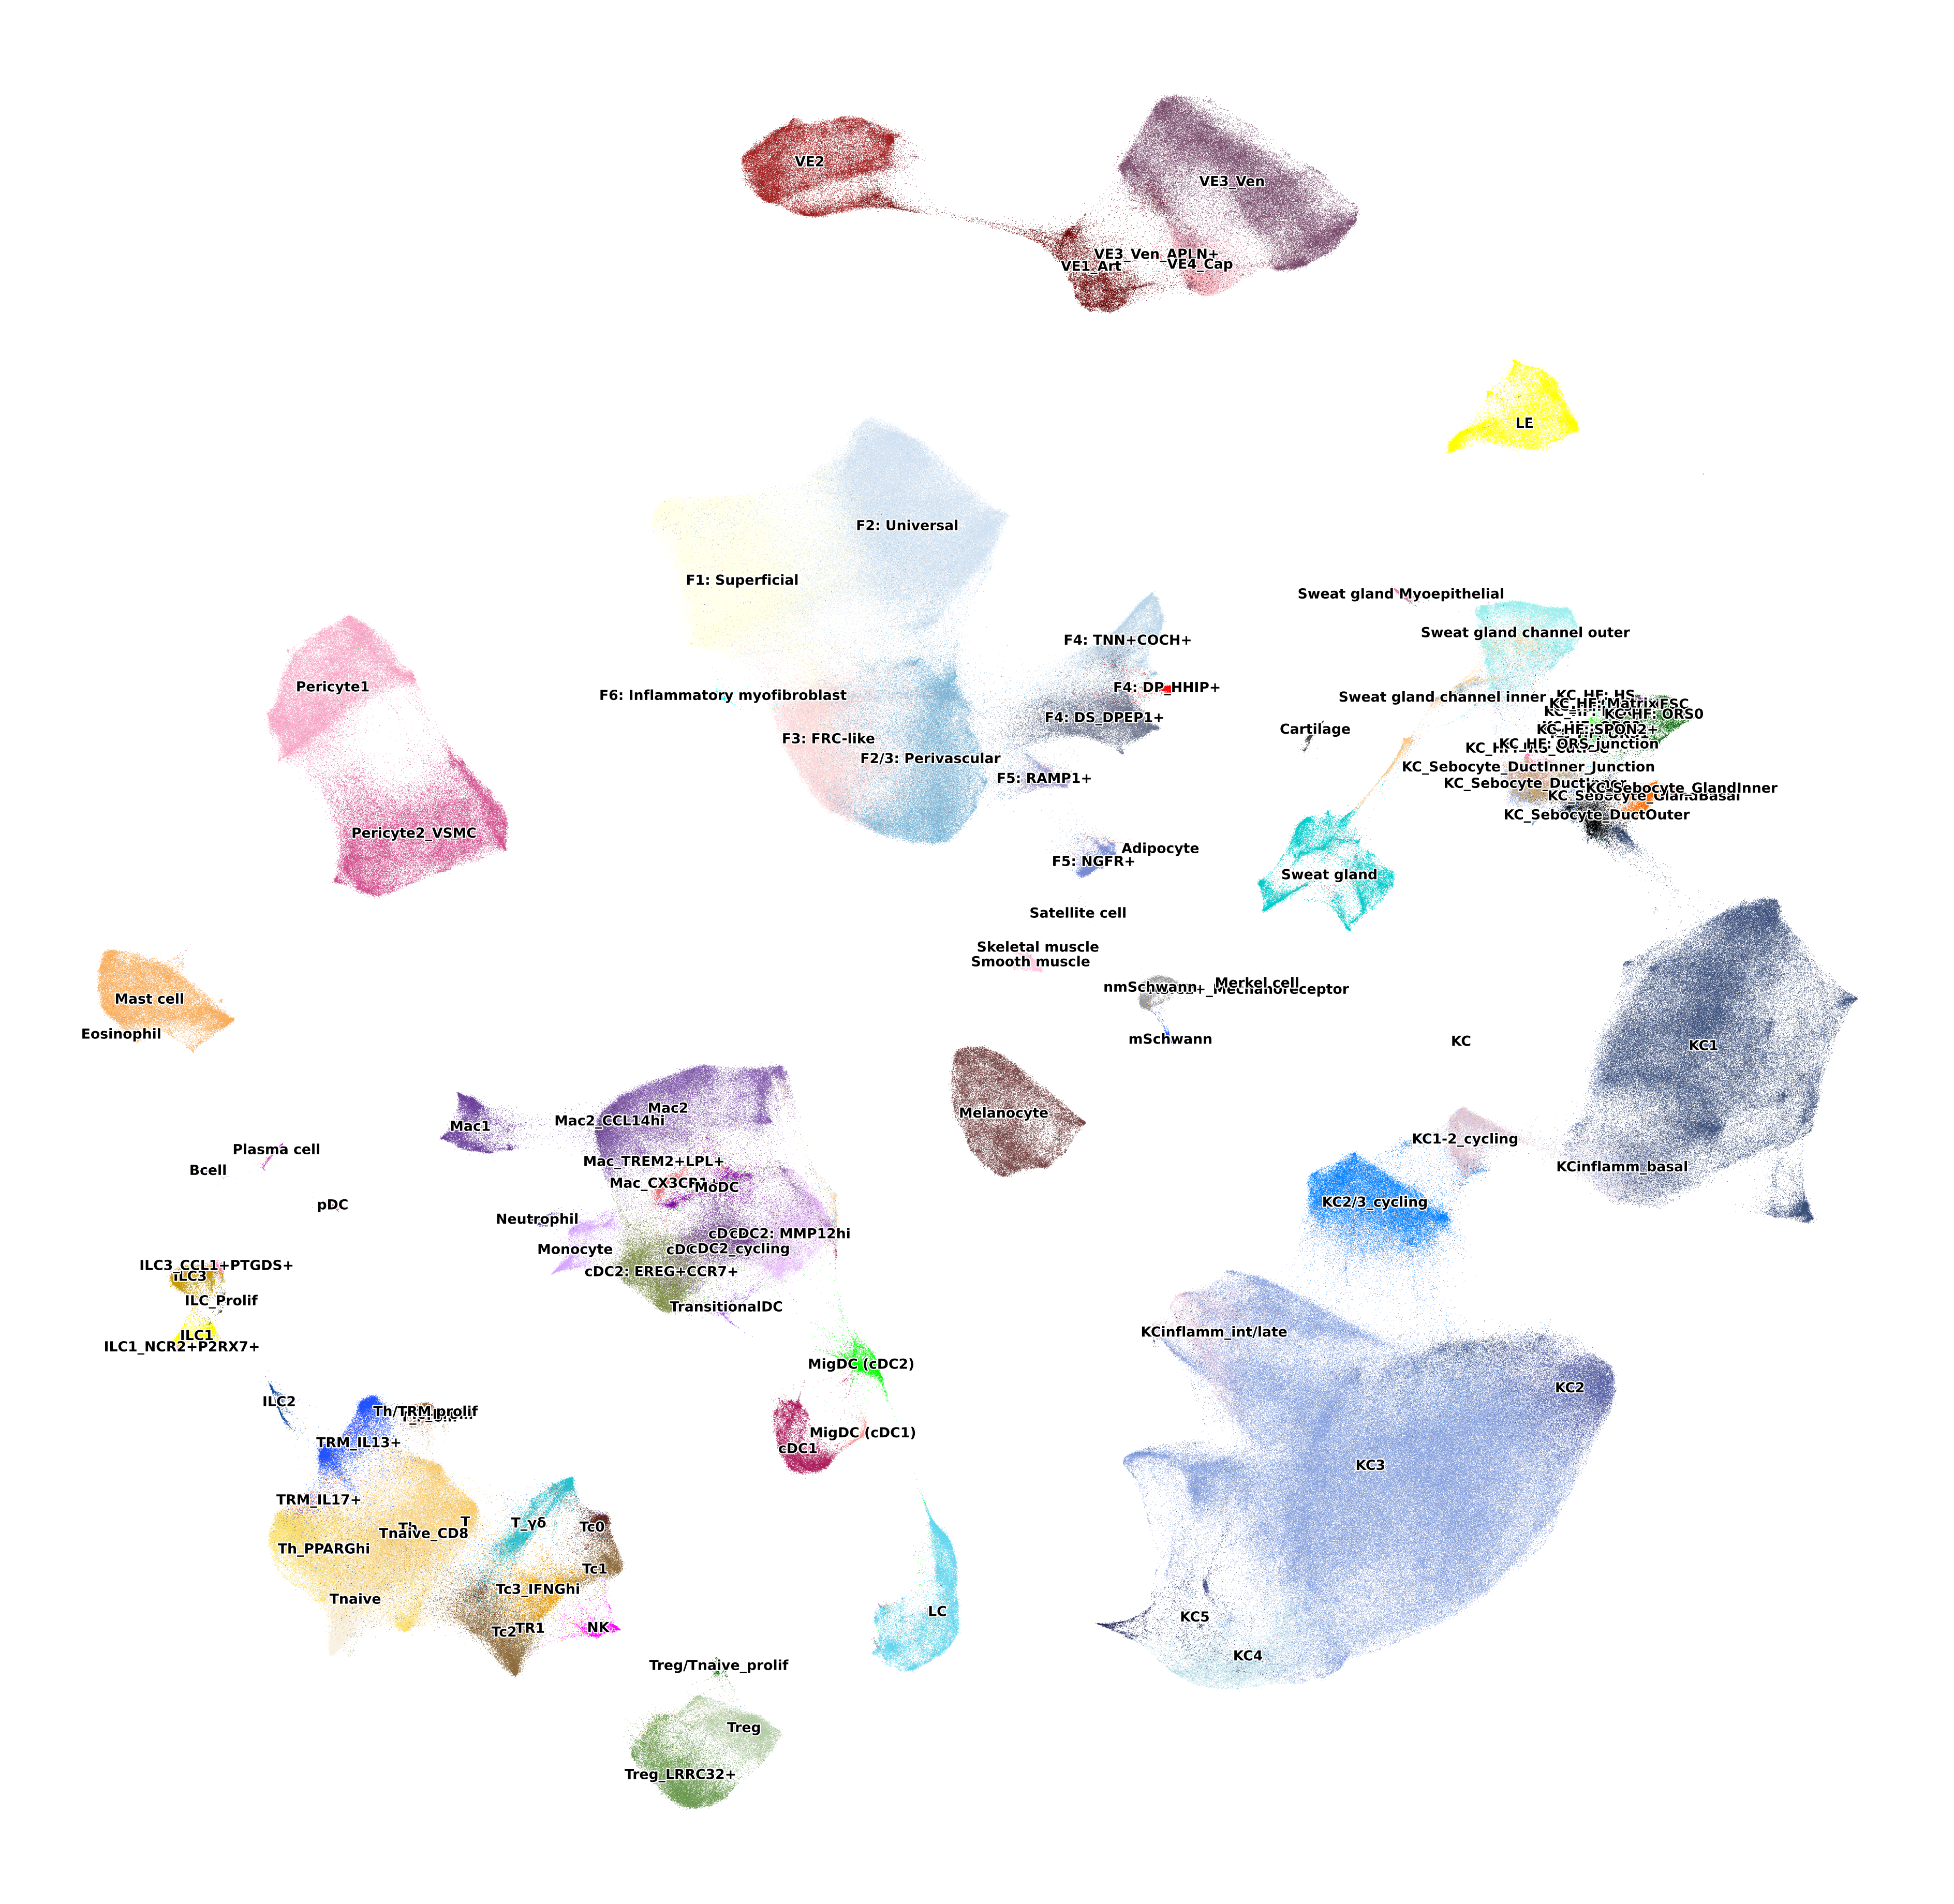

In [8]:
# sc.pl.umap(
#     adata,
#     color=[ "lvl5_annotation"],
#     show=True,
#     frameon=False,
#    # legend_loc= "on data",
#     legend_fontsize=22,
#     s=1,
#     title='',
#     legend_fontoutline=2,
#     save="suppfig13_legend_scrnaumap.pdf"
# )
sc.settings.set_figure_params(dpi_save=900, facecolor="white", frameon=False, figsize=(30,30))

sc.pl.umap(
    adata,
    color=[ "lvl5_annotation"],
    show=True,
    frameon=False,
 legend_loc= "on data",
    legend_fontsize=12,
    s=1,
    title='',
    legend_fontoutline=2,
    save="suppfig13_legendonplot_scrnaumap.pdf"
)
# sc.pl.umap(
#     adata,
#     color=[ "lvl5_annotation"],
#     show=True,
#     frameon=False,
#  legend_loc= "on data",
#     legend_fontsize=12,
#     s=1,
#     title='',
#     legend_fontoutline=2,
#     save="suppfig13_plotonly_scrnaumap.pdf"
# )

# B

In [15]:
ORDER = ['Merkel cell', 'ASIC2+_Mechanoreceptor', 'Adipocyte',  'Eosinophil',
        
    #  'F4: DP_HHIP+', 
         'Mac_CX3CR1+', 'TransitionalDC', ]


In [16]:
adata_i = adata[(adata.obs["lvl5_annotation"].str.startswith("Eos"))|
                (adata.obs["lvl5_annotation"].str.startswith("ASIC"))|
                (adata.obs["lvl5_annotation"].str.startswith("Merke"))|
     #(adata.obs["lvl5_annotation"].str.startswith("ILC"))|
     #(adata.obs["lvl5_annotation"].str.startswith("ILC"))|
        # (adata.obs["lvl5_annotation"].str.startswith("F4: DP"))|
                (adata.obs["lvl5_annotation"].str.startswith("Adip"))|
                #(adata.obs["lvl5_annotation"].str.startswith("Mecha"))|
                (adata.obs["lvl5_annotation"].str.startswith("Mac_CX"))|
                #(adata.obs["lvl5_annotation"].str.startswith("MigDC"))|
                  (adata.obs["lvl5_annotation"].str.startswith("Trans"))
               
               
               ]
adata_i.obs.lvl5_annotation.unique()

['ASIC2+_Mechanoreceptor', 'Mac_CX3CR1+', 'Adipocyte', 'TransitionalDC', 'Merkel cell', 'Eosinophil']
Categories (6, object): ['ASIC2+_Mechanoreceptor', 'Adipocyte', 'Eosinophil', 'Mac_CX3CR1+', 'Merkel cell', 'TransitionalDC']

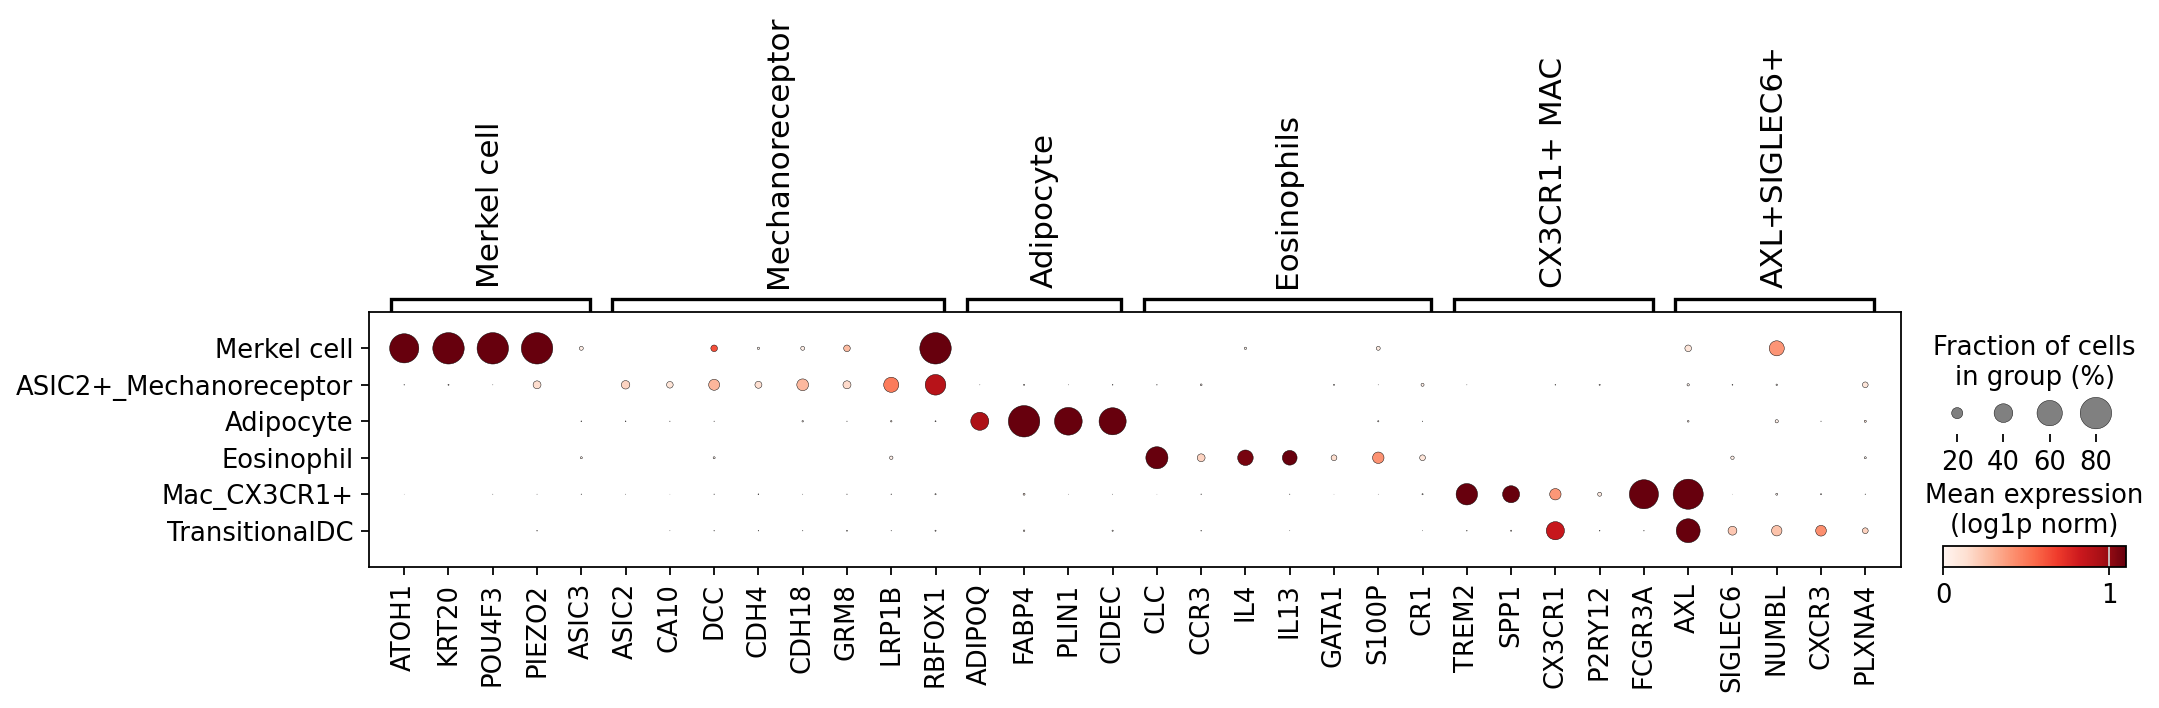

In [19]:
markers = {
    "Merkel cell":       ["ATOH1", "KRT20", "POU4F3", "PIEZO2", "ASIC3"],
    "Mechanoreceptor":   ["ASIC2", "CA10", "DCC", "CDH4", "CDH18", "GRM8", "LRP1B", "RBFOX1"],
    "Adipocyte":         ["ADIPOQ", "FABP4", "PLIN1", "CIDEC"],
    "Eosinophils":       ["CLC", "CCR3", "IL4", "IL13", "GATA1", "S100P", "CR1"],
    "CX3CR1+ MAC":       ["TREM2", "SPP1", "CX3CR1", "P2RY12", "FCGR3A"],
    "AXL+SIGLEC6+":      ["AXL", "SIGLEC6", "NUMBL", "CXCR3", "PLXNA4"],
    #"Migrating":         ["CCR7", "LAMP3"],
   # "cDC1":              ["CLEC9A", "XCR1", "ENPP1"],
   # "McDC2":              ["CLEC10A", "CD1B", "CD1C", "CD1E"],
}

CATEGORY="lvl5_annotation"
sc.pl.dotplot(
    adata_i,
    markers,
    groupby=CATEGORY,
   # standard_scale="var",
    vmax=1.1,
    colorbar_title="Mean expression\n(log1p norm)",
    dendrogram=False,
    categories_order=ORDER,
    save="supp1b_raredotplot_SCrna.pdf",
    dot_max=.8
) 


In [ ]:
S

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
#adata.X[:20,:20].todense()

CATEGORY="lvl5_annotation"

try:
    adata.obs["lvl3_annotation_patient_status"] = adata.obs[CATEGORY].astype(str) + "__" +  adata.obs["Patient_status2"].astype(str)
    #CATEGORY="lvl3_annotation_patient_status"
    adata.obs["lvl3_annotation_patient_status"].value_counts()
except:
    1
adata.obs[CATEGORY].value_counts()



small_cats = adata.obs[CATEGORY].value_counts()
small_cats = small_cats[small_cats < 500]
print(small_cats)


adata_i = adata[#(adata.obs["lvl5_annotation"].str.startswith("Eos"))|
               # (adata.obs["lvl5_annotation"].str.startswith("Adipo"))|
                (adata.obs["lvl5_annotation"].str.startswith("Merke"))|
     (adata.obs["lvl5_annotation"].str.startswith("ILC"))|
     (adata.obs["lvl5_annotation"].str.startswith("ILC"))|
         (adata.obs["lvl5_annotation"].str.startswith("F4: DP"))|
                #(adata.obs["lvl5_annotation"].str.startswith("ASIC"))|
                #(adata.obs["lvl5_annotation"].str.startswith("Mecha"))|
                #(adata.obs["lvl5_annotation"].str.startswith("Mac_CX"))|
                #(adata.obs["lvl5_annotation"].str.startswith("MigDC"))|
                  (adata.obs["lvl5_annotation"].str.startswith("Trans"))
               
               
               ]
adata_i.obs[CATEGORY].value_counts()
RENAME = {'F4: DP_HHIP+': 'F4: DP_HHIP+',
 'ILC1': 'ILC1',
 'ILC1_NCR2+P2RX7+': 'ILC1',
 'ILC1_Prolif': 'ILC1',
 'ILC2': 'ILC2',
 'ILC3': 'ILC3',
 'ILC3_CCL1+PTGDS+': 'ILC3',
 'ILC3_Early': 'ILC3',
 'ILC3_Prolif': 'ILC3',
 'ILC_Stress': 'other',
 'Merkel cell': 'Merkel cell',
 'TransitionalDC': 'TransitionalDC'}
adata_i.obs["lvl4_annotation"]=adata_i.obs["lvl5_annotation"].map(RENAME)
adata_i=adata_i[adata_i.obs["lvl4_annotation"]!="other"].copy()
CATEGORY="lvl4_annotation"


In [ ]:
ORDER = ['F4: DP_HHIP+',  'Merkel cell',  'TransitionalDC',
       'ILC1', 'ILC2', 'ILC3', ]


MARKER_GENES = { 'F4: DP_HHIP+': ['CORIN',
  'BMP7',
  'WNT5A',
  'LEF1',
  'HHIP',
  'RSPO3',
  #'INHBA',
  'PTCH1', "ALPL",   "ALPL", #"TFAP2C","FGFR3", "SH2B2","LAMA3",
],
                  "Merkel cell": ["ATOH1", "KRT20", "POU4F3", #"TRPM2", 
                            "PIEZO2",  ],
     'AXL+SIGLEC6+': ['AXL', 'SIGLEC6', 
                              'CXCR3', 'CX3CR1', 'KDR', #"SELL",
                           #  "TNFSF4", "TCF4"
                             ],
              
    'Innate': [
  'KLRB1',
  'KLRC1',"KLRD1",  "TNFSF10",
  'TYROBP',
  'FCER1G',"XCL2",
],
                       
  #        "NK/ILC1": ['PRF1','KLRD1','TBX21','IRF8',  'KLRF1',
  # 'KLRG1','KLRC2',
  # 'KLRC3', 'CEBPD',"FGR", "EOMES", "IFNG", 'SLA2', 'KIR2DL4', 'SH2D1B', 'SLFN13', 'TMIGD2'],
#  'NK': [  'FCGR3A',
 
#   'CX3CR1',
#   'CCL4L2',
#   'PRSS23', 'B3GAT1',
#        'SPON2',
#   'S1PR5',
#   'AKR1C3',
#          'FGFBP2',



#   'S100B'],

         "ILC1": [# "ADGRG3", "APOBEC3D",
             "GZMA", 'GZMK', 'OASL',  "CXCR3",
             'NCR1',
             'SH2D1A', 'SH2D1B','IL12RB2', 
             
             
             #'NCAM1','P2RX7','ZNF407','IL18','ZBTB20','CASK','ITGA1',
# 'PLCB1','ADAM28','CNR2'
         ],
                 'ILC2': ['GATA3', 'KIT','CXCR6' , 'PTGDR2', 'TNFRSF25',
          'CRLF2',
 # 'IL17RB',
 # 'IL1RL1',

  # 'PPARG',
  # 'PTGS2',
  'PLA2G4A',
  #'IL4',

  'ICOS', 'IL18R1',
#  'NRROS',     'IL31',
#'IL22',
                          'IL13', #"IL5",#'PDLIM4', 'CCL1',
          #'AREG', 'CCR8',
          'IL9R'], 'ILC2+3': [ 'TNFSF11'],
          'ILC3': ['ID3','CSF2', 'KRT86',
 # 'ZBTB46',
  'TNFSF4',
  'SPINK2',
  'RAMP1',
  'MB',
  'KLRF2',
  'TMPRSS11E',"FUT7",
    "THEMIS", "CAMK1", "PECAM1", "CCR8"
                  
                  ],
           #'PTGDS': [  'CCL1',  'PTGDS', 'PDLIM4',
                     #'IL1RN', 'PTGS1', 'PTP4A1'
            #        ],




  #'Naive/Tcm': ['SELL', 'CCR7', 'S1PR1', 'TCF7', 'PAK2', 'ZHX2'],
 #        "NEW": ["PLXDC2", "AIF1", "RAB34", "NEDD4L", "PM20D2", "TNRC18", "JCHAIN", ],

      
        
     
#     "Mechanoreceptor": ["ASIC2","CA10", "DCC", "CDH4", "CDH18","GRM8",
#                         "LRP1B", #"IL1RAPL1","CTNNA2", "SUGCT", "NRXN1", "OPCML", 
#                "RBFOX1", #"DOK6", 
#                #"HYDIN", #"RYR3",
#              #  "RALYL", "GRM7", "NDST3",  'CSMD1','LHFPL3'
#                #"HULC", "RYR3", "DMD", "ROBO2", "TENM2", "NRG3", "PCAT1", "CACNA2D3", 
#                #"DLC1", "NAV3"
              
#                        ],
   # "Other ASIC": ["ASIC1", "ASIC4"],
    
   
#         "Adipocyte": ["ADIPOQ",  "FABP4", "PLIN1", "CIDEC"],
# # 'TREM2+ADAMDEC1+': ['TREM2', 'CXCL5', 'EPHB2', 'STAC', 'FAM20C'],
#      "Eosinophils": [ "CLC", "CCR3",# "CCL23",
#        "IL4", "IL13", #"IL5", "IL9",
#                                    "GATA1",  "S100P", 
#             "CR1",
#                #                      #"CACNA1D",  "MS4A3", "TCN1", "PRSS3", "CYP11A1", "KLF5",
#                # "EGR3", "TNFSF11", "CD200R1", "IL1RL1", "ADGRG3", "NDFIP2",
#                # "LYPD6B","CACNG8", "KRT81", "CYP11A1", 
#                # "PTGDR2", "P2RY1","CHRM3-AS2","IL18RAP",

#  'CX3CR1+MAC': ['TREM2', 'SPP1', # "LPL", 
#                 'CX3CR1', #'ADRB1', 
#               # "KCNQ3"#"UNC5B", "GPR34", "SMAD7",  "CD72", "TGFBR1", 
#              #  "CD9",
               
#                 "P2RY12", #'ADAMDEC1',
#                  'FCGR3A', 
#                 # 'TGFBR1', 'PRKCH', 'CD93',# 'HTRA1',
#                 # "ADRB1",
#                ], 
                 
           
      #  "Plasma_in_immuneonc": ["MZB1", "CENPV", "CXCL13", "RORC", "MCEMP1", "AIRE"]

               
}
CATEGORY="lvl4_annotation"
sc.pl.dotplot(
    adata_i[adata_i.obs["tech"]!="xenium"],
    remove_markers(MARKER_GENES),
    groupby=CATEGORY,
   # standard_scale="var",
    vmax=1.1,
    colorbar_title="Mean expression\n(log1p norm)",
    dendrogram=False,
    categories_order=ORDER,
    save="supp1b_raredotplot_SCrna.pdf",
    dot_max=.8
) 


sc.pl.dotplot(
    adata_i[adata_i.obs["tech"]=="xenium"],
    remove_markers(MARKER_GENES),
    groupby=CATEGORY,
   # standard_scale="var",
    vmax=1.1,
    colorbar_title="Mean expression\n(log1p norm)",
    dendrogram=False,
    categories_order=ORDER,
    #save="supp_raredotplot.pdf",
    dot_max=.4
) 


In [ ]:
S

# lvl1 

In [ ]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.nohealthy'
adata=sc.read_h5ad(PATH)
adata.obs["lvl5_annotation"].nunique()

In [ ]:
adata_5k=adata[adata.obs["tech"]=="xenium"].copy()
adata=adata[adata.obs["tech"]!="xenium"].copy()
import gc
gc.collect()

In [ ]:
adata.obs["lvl5_annotation"].nunique()

In [ ]:
adata_5k.obs["lvl5_annotation"].nunique()

In [ ]:
print("Unique to scRNA\n")

scrna_celltypes4=set(adata.obs["lvl5_annotation"].unique())
xenium_celltypes4=set(adata_5k.obs["lvl5_annotation"].unique())
for x in scrna_celltypes4:
    if x not in xenium_celltypes4:
        print(x)



In [ ]:
print("Unique to Xenium\n")
for x in xenium_celltypes4:
    if x not in scrna_celltypes4 :
        print(x)


In [ ]:
print("scrna cell types lvl4: ", adata.obs["lvl4_annotation"].nunique())
print("xenium cell types lvl4: ", adata_5k.obs["lvl4_annotation"].nunique())

print()
shared_types = scrna_celltypes4 & xenium_celltypes4  # or .intersection()
print("Number of shared lvl4_annotation types:", len(shared_types))

In [ ]:
# adata.obs["lvl5_annotation"]=

In [ ]:
adata.obs["tech"].value_counts()

In [ ]:
{x:x for x in adata.obs["lvl1_new"].unique()}

In [ ]:
colors = {
    'KC': '#91b6f2',              # pastel blue
    'Myeloid': '#b29ac9',         # soft pastel purple
    'VE/Pericyte/muscle': '#e28a8a',  # muted coral red
    'Sweat gland': '#8ed4d0',     # pastel turquoise
    'Fibroblast': '#f2b880',      # soft orange
    'Other': '#a47551',           # earthy brown
    'KC_HF': '#9ec69c',           # gentle green
    'T': '#e8d8b3',               # pastel beige
    'Schwann': '#6c6c6c',         # soft dark grey
    'ILC': '#f5e572'              # muted yellow
}

In [ ]:
adata.obs['lvl1_new'] =adata.obs['lvl1_new'] .astype('category')
adata.uns['lvl1_new_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata.obs['lvl1_new'].cat.categories]






In [ ]:

sc.pl.umap(
    adata,
    color=[ "lvl1_new"],
    show=True,
    frameon=False,
    legend_loc= "on data",
    legend_fontsize=22,
    s=10,
    title='',
    legend_fontoutline=2,
  save="1b_scrna_lvl1.pdf"
)
print(adata.shape)

In [ ]:

sc.pl.umap(
    adata,
    color=[ "lvl1_new"],
    show=True,
    frameon=False,
    legend_loc= "on data",
    legend_fontsize=22,
    s=1,
    title='',
    legend_fontoutline=2,
  save="1b_scrna_lvl1_smallerdotsize.pdf"
)
print(adata.shape)

# check agreement

In [ ]:
# for s in adata.obs["tech"].unique():
#     ref_s = adata.copy()
#     ref_s.obs.lvl1_new[ref_s.obs.tech != s] = np.nan

#     sc.pl.umap(ref_s,
#                color=['lvl1_new'],
#                frameon=False,
#                wspace=0.6, s=10,
#                #palette=sns.color_palette('colorblind', as_cmap=True), title=s,
#                #save=s+'.pdf'
#                )

In [ ]:
{x:x for x in sorted(adata.obs["lvl5_annotation"].unique())}

In [ ]:
RENAME = {'ASIC2+_Mechanoreceptor':  'Other',
 'Adipocyte': 'Adipocyte',
 'Bcell': 'B-lineage',
 'Cartilage': 'Cartilage',
 'Eosinophil': 'Other',
 'F1: Superficial': 'Fibroblast',
 'F2/3: Perivascular': 'Fibroblast',
 'F2: Universal': 'Fibroblast',
 'F3: FRC-like': 'Fibroblast',
 'F4: DP_HHIP+':'Fibroblast',
 'F4: DS_DPEP1+': 'Fibroblast',
 'F4: TNN+COCH+': 'Fibroblast',
 'F5: NGFR+':  'Fibroblast',
 'F5: RAMP1+': 'Fibroblast',
 'F6: Inflammatory myofibroblast':  'Fibroblast',
 'ILC1': 'ILC',
 'ILC1_NCR2+P2RX7+':'ILC',
 'ILC2': 'ILC',
 'ILC3': 'ILC',
 'ILC3_CCL1+PTGDS+': 'ILC',
 'ILC_Prolif':'ILC',
 'KC': 'KC',
 'KC1': 'KC',
 'KC1-2_cycling': 'KC',
 'KC2': 'KC',
 'KC2/3_cycling': 'KC',
 'KC3': 'KC',
 'KC4': 'KC',
 'KC5': 'KC',
 'KC_HF: HFSC': 'Hair follicle',
 'KC_HF: HS': 'Hair follicle',
 'KC_HF: IRS0': 'Hair follicle',
 'KC_HF: IRS1':'Hair follicle',
 'KC_HF: IRS_cycling': 'Hair follicle',
 'KC_HF: ORS0': 'Hair follicle',
 'KC_HF: ORS1':'Hair follicle',
 'KC_HF: ORS2': 'Hair follicle',
 'KC_HF: ORS_cycling': 'Hair follicle',
 'KC_HF: ORS_junction': 'Hair follicle',
 'KC_HF_SPON2': 'Hair follicle',
 'KC_HS: HS_TRPV1+':'Hair follicle',
 'KC_Sebocyte_DuctInner': 'Sebaceous_gland',
 'KC_Sebocyte_DuctInner_Junction': 'Sebaceous_gland',
 'KC_Sebocyte_DuctOuter':'Sebaceous_gland',
 'KC_Sebocyte_GlandBasal':'Sebaceous_gland',
 'KC_Sebocyte_GlandInner':'Sebaceous_gland',
 'KCinflamm_basal': 'KC',
 'KCinflamm_int/late': 'KC',
 'LC': 'DC',
 'LE': 'Lymphatic endothelium',
 'Mac1':'Mac/Mono',
 'Mac2': 'Mac/Mono',
 'Mac2_CCL14hi':'Mac/Mono',
 'Mac_CX3CR1+': 'Mac/Mono',
 'Mac_TREM2+LPL+': 'Mac/Mono',
 'Mast cell': 'Mast cell',
 'Melanocyte': 'Melanocyte',
 'Merkel cell':  'Other',
 'MigDC (cDC1)': 'DC',
 'MigDC (cDC2)': 'DC',
 'MoDC': 'DC',
 'Monocyte': 'Mac/Mono',
 'NK':'ILC',
 'Neutrophil': 'Other',
 'Pericyte1': 'Pericyte',
 'Pericyte2_VSMC': 'Pericyte',
 'Plasma cell':  'B-lineage',
 'Satellite cell':  'Other',
 'Skeletal muscle': 'Muscle',
 'Smooth muscle': 'Muscle',
 'Sweat gland': 'Sweat gland',
 'Sweat gland Myoepithelial': 'Sweat gland',
 'Sweat gland channel inner': 'Sweat gland',
 'Sweat gland channel outer': 'Sweat gland',
 'T': 'T',
 'TR1':'T',
 'TRM_IL13+':'T',
 'TRM_IL17+': 'T',
 'T_Prolif': 'T',
 'T_γδ': 'T',
 'Tc0': 'T',
 'Tc1': 'T',
 'Tc2': 'T',
 'Tc3_IFNGhi': 'T',
 'Tc_Prolif': 'T',
 'Th': 'T',
 'Th/TRM prolif': 'T',
 'Th_PPARGhi': 'T',
 'Tnaive': 'T',
 'TransitionalDC': 'DC',
 'Treg': 'T',
 'Treg/Tnaive_prolif': 'T',
 'Treg_LRRC32+': 'T',
 'VE1_Art': 'Vascular endothelium',
 'VE2': 'Vascular endothelium',
 'VE3_Ven': 'Vascular endothelium',
 'VE3_Ven_APLN+': 'Vascular endothelium',
 'VE4_Cap': 'Vascular endothelium',
 'cDC': 'DC',
 'cDC1': 'DC',
 'cDC2': 'DC',
 'cDC2: EREG+CCR7+': 'DC',
 'cDC2: MMP12hi': 'DC',
 'cDC2_cycling': 'DC',
 'mSchwann': 'Schwann',
 'nmSchwann': 'Schwann',
 'pDC': 'DC'}
adata.obs["lvl2"]=adata.obs["lvl5_annotation"].map(RENAME).fillna(adata.obs["lvl2"])
adata.obs["lvl2"].value_counts()

In [ ]:
# {x:x for x in sorted(adata.obs["lvl2"].unique())}

In [ ]:
celltype_colors = {
    'Adipocyte': '#FAF9F6',          # almost white, creamy linen
    'B-lineage': '#7DAFFF',          # soft cornflower blue
    'Cartilage': '#B8B8B8',          # misty grey
    'DC': '#A18BD0',                 # lavender purple
    'Fibroblast': '#A7C7E7',         # light powder blue
    'Granulocyte': '#FFB347',        # warm apricot orange
    'Hair follicle': '#8FBF87',      # moss green
    'ILC': '#F5E86C',                # sunny yellow
    'KC': '#6A9FD8',                 # medium sky blue
    'Lymphatic endothelium': '#F9F3A6', # pale butter yellow
    'Mac/Mono': '#C6A5D9',           # lilac purple
    'Mast cell': '#E67E30',          # muted pumpkin orange
    'Melanocyte': '#7B4B3A',         # warm earthy brown
    'MigDC': '#7FD49B',              # fresh mint green
    'Muscle': '#F2AFC1',             # blush pink
    'Other': '#D9D9D6',              # light grey
    'Pericyte': '#F6C1D0',           # pastel rose pink
    'Schwann': '#555B61',            # deep slate grey
    'Sebaceous_gland': '#E89C59',    # muted tangerine
    'Sweat gland': '#7FD1C1',        # soft turquoise
    'T': '#E6D3B3',                  # parchment beige
    'Vascular endothelium': '#B65C5C' # muted dark red
}

In [ ]:
adata.obs['lvl2'] =adata.obs['lvl2'] .astype('category')
adata.uns['lvl2_colors'] = [celltype_colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata.obs['lvl2'].cat.categories]






In [ ]:

sc.pl.umap(
    adata,
    color=[ "lvl2"],
    show=True,
    frameon=False,
    legend_loc= "on data",
    legend_fontsize=18,
    s=0.5,
    title='',
    legend_fontoutline=2,
    alpha=0.6
 # save="1b_scrna_lvl1_smallerdotsize.pdf"
)
print(adata.shape)

In [ ]:
adata = adata[~adata.obs["lvl2"].isna()]

In [ ]:

sc.pl.umap(
    adata,
    color=[ "lvl2"],
    show=True,
    frameon=False,
    legend_loc= "on data",
    legend_fontsize=32,
    s=0.1,
    title='',
    legend_fontoutline=2,
    alpha=1,
        save="fig_1c_umap_fontdiff.pdf"

 # save="1b_scrna_lvl1_smallerdotsize.pdf"
)
print(adata.shape)



sc.pl.umap(
    adata,
    color=[ "lvl2"],
    show=True,
    frameon=False,
    legend_loc= "on data",
    legend_fontsize=24,
    s=1,
    title='',
    legend_fontoutline=2,
    alpha=0.4,
    linewidth=0.001,
    edgecolor='lightgrey',
    save="fig_1c_umap.pdf"
 # save="1b_scrna_lvl1_smallerdotsize.pdf"
)
print(adata.shape)

sc.pl.umap(
    adata,
    color=[ "lvl2"],
    show=True,
    frameon=False,
   # legend_loc= "on data",
    legend_fontsize=38,
    s=1,
    title='',
    legend_fontoutline=2,
    alpha=0.4,
    linewidth=0.001,
    edgecolor='lightgrey',
    save="fig_1c_umap_notext.pdf"
 # save="1b_scrna_lvl1_smallerdotsize.pdf"
)
print(adata.shape)

In [ ]:
print(adata.shape)

In [ ]:

# sc.pl.umap(
#     adata,
#     color=[ "lvl2"],
#     show=True,
#     frameon=False,
#     legend_loc= "on data",
#     legend_fontsize=18,
#     s=1,
#     title='',
#     legend_fontoutline=2,
#     alpha=0.6
#  # save="1b_scrna_lvl1_smallerdotsize.pdf"
# )
# print(adata.shape)

In [ ]:
adata.obs["fig8_mapping"].value_counts()

# more detailed

In [ ]:
# PATH = '/nfs/team298/ls34/new_disease_atlas/model_XENIUMLABELT_final_xenium_paper_1544/adata_all_scvi7.h5ad.countsonly.clustered_leidenres1'
# adata=sc.read_h5ad(PATH)


In [ ]:
# sc.pl.umap(
#     adata,
#     color=[ "lvl5_annotation"],
#     show=True,
#     frameon=False,
#     legend_loc= "on data",
#     legend_fontsize=12,
#     s=10,
#     title='',
#     legend_fontoutline=2,
#  # save="1b_scrna.pdf"
# )
# print(adata.shape)

In [ ]:
# FILE_NAME = 'adata_xenium_freeze_plus3d.h5ad.v2'

# PATH=f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}'

# adata_5k=sc.read_h5ad(PATH)
# # adata_5k.obs["Timepoint2"].value_counts()
# #adata_5k=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_xenium_v1.h5ad.final')
# def remove_markers(LIST):
#     try: 
#         LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
#                            for key, genes in LIST.items()}
#     except: 
#         LIST =[gene for gene in LIST if gene in adata_5k.var_names]
#     return LIST



# adata_5k.obs["lvl5_annotation_new"]=adata_5k.obs["lvl4_annotation"]
# adata_5k.obs["Sanger patient ID"].nunique()
adata_5k=adata[adata.obs["tech"]=="xenium"]



In [ ]:
adata_5k.obs["Sanger patient ID"].nunique()


In [ ]:
print("Unique to scRNA\n")

scrna_celltypes4=set(adata.obs["lvl5_annotation"].unique())
xenium_celltypes4=set(adata_5k.obs["lvl5_annotation"].unique())
#xenium_celltypes4_ns = set(adata_5k_nononspecific.obs["lvl5_annotation"].unique())
for x in scrna_celltypes4:
    if x not in xenium_celltypes4:
        print(x)

In [ ]:
print("Unique to Xenium\n")
for x in xenium_celltypes4:
    if x not in scrna_celltypes4 :
        print(x)

In [ ]:
print("Unique to scrna\n")
for x in scrna_celltypes4 :
    if x not in  xenium_celltypes4:
        print(x)

In [ ]:

print("scrna cell types lvl4: ", adata.obs["lvl5_annotation"].nunique())
print("xenium cell types lvl4: ", adata_5k.obs["lvl5_annotation"].nunique())

print()
shared_types = scrna_celltypes4 & xenium_celltypes4  # or .intersection()
print("Number of shared lvl5_annotation types:", len(shared_types))

In [ ]:
styop

# xenium only

In [ ]:
PATH = '/nfs/team298/ls34/new_disease_atlas/model_XENIUMLABELT_final_xenium_paper2_1929/adata_all_scvi7.h5ad.countsonly.clustered'
adata=sc.read_h5ad(PATH)

In [ ]:
sc.settings.set_figure_params(dpi_save=900, facecolor="white", frameon=False, figsize=(30,30))

sc.pl.umap(
    adata,
    color=[ "lvl5_annotation_all"],
    show=True,
    frameon=False,
    #legend_loc= "on data",
    legend_fontsize=32,
    s=10,
    title='',
    legend_fontoutline=2,
    alpha=1,
       # save="fig_1c_umap_fontdiff.pdf"

 # save="1b_scrna_lvl1_smallerdotsize.pdf"
)
print(adata.shape)




In [ ]:
adata

In [ ]:
1

In [ ]:
0

In [ ]:
adata_5k.obs["Sanger patient ID"].nunique()


In [ ]:
# adata_5k.obs.lvl4_annotation.value_counts()

In [ ]:
[x for x in adata_5k.obs.scanvi_predictions.unique() if x.startswith("T")]

In [ ]:
# adata_5k.obs["lvl4_annotation"]=adata_5k.obs["scanvi_predictions"]

In [ ]:
1

In [ ]:
1

In [ ]:
# FILE_NAME = "adata_xenium_freeze.h5ad"  #"adata_xenium_v3.h5ad.final.timepointsforpaper"
# PATH=f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}'
# adata_5k.write(PATH)

In [ ]:
# #FILE_NAME = "adata_scrna_v3.h5ad.final"
# PATH2_FILE=f'/nfs/team298/ls34/adult_skin/final_adatas/adata_scrna_freeze.h5ad'
# # adata.write(f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}')
# adata=sc.read_h5ad(PATH2_FILE)
# # try:
# #     adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_scrna_v1.h5ad.final')
# # except:
# #     import scanpy as sc
# #     adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_scrna_v1.h5ad.final')

# adata.obs["lvl5_annotation_new"]=adata.obs["lvl5_annotation"]

# # #adata=adata[adata.obs["tech"]!="xenium"]
# # adata

# adata



 

In [ ]:
# adata[adata.obs["DonorID"]=="E1"].shape

In [ ]:
# FILE_NAME = "adata_scrna_freeze.h5ad"
# adata.write(f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}')

# CHECK CELL TYPES

In [ ]:
# RENAME = {
#      'Tc_IL9R+GPR15hi': 'Tc0',
#     'Tc_GPR15hi': 'Tc0',
#     "Tc_ZNF683+": 'T_γδ',
#         "Tc_ZNF683": 'T_γδ',


# }
# adata.obs["lvl4_annotation"]=adata.obs["lvl4_annotation"].map(RENAME).fillna(adata.obs["lvl4_annotation"])

In [ ]:
# RENAME = {
#      'Tc_IL9R+GPR15hi': 'Tc0',
#     'Tc_GPR15hi': 'Tc0',
#     "Tc_ZNF683+": 'T_γδ',
#         "Tc_ZNF683": 'T_γδ',


# }
# adata_5k.obs["lvl4_annotation"]=adata_5k.obs["lvl4_annotation"].map(RENAME).fillna(adata_5k.obs["lvl4_annotation"])
# adata_5k_nononspecific.obs["lvl4_annotation"]=adata_5k_nononspecific.obs["lvl4_annotation"].map(RENAME).fillna(adata_5k_nononspecific.obs["lvl4_annotation"])



# LVL 4

In [ ]:
# adata_5k_nononspecific=adata_5k[adata_5k.obs["lvl4_annotation"]!="Non-specific"]

In [ ]:
stop

In [ ]:
adata_5k_nononspecific = sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_xenium_v3.h5ad.final.timepointsforpaper.intergatedwithoutnonspecific')


In [ ]:
print("Unique to scRNA\n")

scrna_celltypes4=set(adata.obs["lvl5_annotation"].unique())
xenium_celltypes4=set(adata_5k.obs["lvl5_annotation"].unique())
xenium_celltypes4_ns = set(adata_5k_nononspecific.obs["lvl5_annotation"].unique())
for x in scrna_celltypes4:
    if x not in xenium_celltypes4:
        print(x)

In [ ]:




print("Unique to Xenium\n")
for x in xenium_celltypes4:
    if x not in scrna_celltypes4 :
        print(x)


In [ ]:





print("Unique to Xenium\n")
for x in xenium_celltypes4_ns:
    if x not in scrna_celltypes4 :
        print(x)


In [ ]:

print("scrna cell types lvl4: ", adata.obs["lvl4_annotation"].nunique())
print("xenium cell types lvl4: ", adata_5k.obs["lvl4_annotation"].nunique())

print()
shared_types = scrna_celltypes4 & xenium_celltypes4  # or .intersection()
print("Number of shared lvl4_annotation types:", len(shared_types))

In [ ]:
# print("Unique to scRNA\n")

# scrna_celltypes5=set(adata.obs["lvl5_annotation"].unique())
# xenium_celltypes5=set(adata_5k.obs["lvl5_annotation"].unique())
# for x in scrna_celltypes5:
#     if x not in xenium_celltypes5:
#         print(x)

In [ ]:

# print("Unique to Xenium\n")
# for x in xenium_celltypes5:
#     if x not in scrna_celltypes5:
#         print(x)


# set colors

In [ ]:
colors = {'Adipocyte': '#B8860B',
 'F1: Superficial': '#FFFFE4',
 'F1: Regenerative': '#FFFFE4',
 'F2/3: Perivascular': '#78b5d7',
 'F2: Universal': '#d0e1f2',
 'F3: FRC-like': '#fbd4d7',
 'F4: DS_DPEP1+': '#d3eec9',
 'F4: TNN+COCH+': '#80ca80',
 'F5: NGFR+': '#788bd2',
 'F5: RAMP1+': '#9e99c9',
 'F6: Inflammatory myofibroblast': '#00ffff',
 'KC1/2': '#505aa1',
 'KC2/3_cycling': '#007FFF',
 'KC_cycling': '#007FFF',
 'KC3': '#839edd',
 'KC4': '#b1dae6',
 'KC5': '#272c5f',
 'KC_HF: Basal': '#006400',
 'KC_HF: m': '#abe8bd',
 'KC_HF: HS': '#abe8bd',
 'KC_HF: IRS+HS': '#abe8bd',
 'KC_SebocyteGland_Outer': '#fe5e00',
 'KC_SebocyteGland_Inner': '#ffff33',
 'KC_SebocyteDuct_Outer/HF_Junction': '#5C430F',
 'KC_SebocyteDuct_Outer': '#958159',
 'KC_SebocyteDuct_Inner': '#f6d7b0',
 'KC_HF: ORS0': '#003200',
 'KC_HF: ORS1': '#9ad295',
 'KC_HF: ORS1/2': '#9ad295',
 'KC_HF: ORS2': '#e7f9e5',
 'KC_HF: IRS': '#ff083a',
 'KC_HF: IRS_cycling': '#FF849D',
 'KC: HF ORS1/2': '#94cb72',
 'KC_HF: IRS+HS_medulla': '#94cb72',
 'KC_HF: IRS_TCHH+': '#990523',
 'KC_SC: LGR6+ACTA2+': '#008080',
 'KCinflamm_basal/int': '#f4e9ef',
 'KCinflamm_late': '#D49BB1',
 'LC': '#63D7F0',
 'LC_SLC18A2+': '#3bc1d9',
 'LE': '#FFFF00',
 'Mac': '#845DAE',
 'Mac2': '#845DAE',
 'Mac2_CCL14hi': '#4F2F6D',
 'Mast cell': '#f8ac59',
 'Melanocyte': '#6f3a3a',
 'MigDC': '#00FF00',
 'MigDC (cDC2)': '#00FF00',
 'MigDC (cDC1)': '#FF9999',
 'Smooth muscle': '#f371af',
 'Nonspecific': '#D3D3D3',
 'Pericyte1': '#F7A3C3',
 'Pericyte2_VSMC': '#D04A8A',
 'Plasma cell': '#ff5e00',
 'KC_Sebocyte_basal': '#e28743',
 'KC_Sebocyte_inner': '#ffd1a3',
 'KC_Sebocyte': '#ffd1a3',
 'Sweat gland': '#00CCCC',
 'Sweat gland channel': '#2DA8A0',
 'Sweat gland channel_inner': '#FFE5B4',
 'Sweat gland channel inner': '#FFE5B4',
 'Sweat gland channel_outer': '#B3FFF0',
 'Sweat gland channel outer': '#B3FFF0',
 'Sweat gland Myoepithelial': '#f275ae',
 'T': '#F4D1A1',
 'T_Prolif': '#D4B082',
 'Tc': '#8C6A3B',
 'Tc1': '#8C6A3B',
 'Tc2': '#8C6A3B',
 'Tc_IL9R+GPR15hi': '#5a1f16',
          
 'Tnaive': '#F9F2E4',
 'Treg': '#B2CBA4',
 'Treg_LRRC32+': '#68984c',
 'VE2': '#9f1a1a',
 'VE': '#9f1a1a',
 'VE1_Art': '#660000',
 'VE3_Ven': '#764869',
 'VE4_Cap': '#FFB6C1',
 'VE3_Ven_APLN+': '#FF073A',
 'cDC1': '#ac1d5c',
 'cDC2': '#6F478C',
 'cDC2: MMP12hi': '#f71886',
 'mSchwann': '#555555',
 'nmSchwann': '#999999',
 'pDC': '#D85B8C',
 'cDC2: EREG+CCR7+': '#7B8B43',
 'TransitionalDC': '#9b4ef5',
 'Bcell':  "#1E90FF",  # DodgerBlue – not already used
 'Cartilage': '#404040',
 'F4: DP_HHIP+': '#26a83f',
 'F4: HF-associated': '#26a83f',
 'F_Fascia': '#000000',
 'ILC1': '#FFFF00',
 'ILC1_NCR2+P2RX7+': '#c18bcb',
 'ILC1_NK': '#F4D03F',
 'ILC1/NK': '#F4D03F',
 'ILC2': '#F1C40F',
 'ILC2/3': '#F1C40F',
 'ILC3': '#C79A00',
 'ILC3 CCL1+PTGDS+': '#ff68b4',
            'ILC3_CCL1+PTGDS+': '#ff68b4',

 'ILC_Prolif': '#3F3100',
 'ILC_prolif': '#3F3100',
 'KC1': '#3a4e7a',
 'KC2': '#505aa1',
 'KC_HF: ORS_cycling': '#00b300',
 'KC_HF: Basal_NPNT+': '#006400',
 'KC_HF': '#006400',
 'KCinflamm_basal': '#f9f3fb',
 'KCinflamm': '#f9f3fb',
 'KCinflamm_int/late': '#e9c8dc',
 'KCinflamm_cycling': '#e0c5d2',
 'KC1-2_cycling': '#e0c5d2',
 'KCinflamm_int': '#f5d3e7',
 'LC_CCR7+': '#3bc1a4',
 'Mac1': '#6A3F9B',
 'Mac_CX3CR1+': '#9D1A80',
 'Mac_TREM2+LPL+': '#D2C5E1',
 'Merkel cell': '#2f2f2f',
 'MoDC': '#7F00A2',
 'MoDC/cDC2: MMP12+': '#7F00A2',
 'MoDC/cDC2': '#7F00A2',
 'Monocyte': '#D8A7FF',
 'Mono CD16+': '#E1C6FF',
 'NK': '#FF00FF',
 'Neutrophil': '#4D3F8C',
 'Satellite cell': '#F387C7',
 'Skeletal muscle': '#F14D8E',
 'Tc_IFNGhi': '#F5A600',
 'Tc3_IFNGhi': '#F5A600',
 'TRM_IL13+': '#7795cc',
 'TRM_IL17+': '#E63238',
 'Tc_ZNF683+': '#D4B082',
 'Th': '#F9CA67',
 'Th_PPARGhi': '#FAE064',
 'Th_CXCR6+': '#F48B50',
 'TR1': '#E3F2DC',
 'cDC2: IL1B+': '#B78FE1',
 'cDC2_cycling': '#9272B4',
 'Eosinophil': '#FF5F00',
 'Mechanoreceptor ASIC2+': '#D3D3D3',
           'ASIC2+_Mechanoreceptor':  '#D3D3D3',
 'Tc_γδ': '#28c1d0',
      'T_γδ': "#28c1d0",

 'Tc0': '#5a1f16',
 'Th_PPARGhi_IL17': '#FFE064',
 'Tfh-like': '#d8e4e2',
 'Th2': '#b8bde3',
 'ILC3_prolif': '#503E00',
 'ILC1_prolif': '#666600',
 'ILC_SELL+CCR7+': '#FFFFCC',
         
         
#          "KC_HF: IRS_Cuticle":        "#E97388",
    
#         "KC_HF: HS Xenium":     "#0000FF",
#     "KC_HF: HS":           "#8A0C26",
    
    
#  "KC_HF: HS scRNA":      "#FF69B4",
    
#     "Other":                "#F3F3F3",
    
    
   


#     "KC_HF: ORS0":          "#006400",
#     "KC_HF: ORS1":          "#66C266",
#     "KC_HF: ORS2":        "#39FF14",   #  #"#FF69B4",
#     "KC_HF: ORS_cycling":    "#267326" , #"#000000",
#         "KC_HF: ORS_junction":   "#D6FFD0",  #"#8C8C8C", #    '#D7FFD0',
#         "KC_HF: ORS-Bulb/infundibulum": "#0071e8" ,#like sebocyte gland#"#FF4500", # ve pale green"#F3FFF3",  #"#F3CCD7",

    
    
#     "KC_HF: IRS":           "#0000FF",
#     "KC_HF: IRS0":          "#FFA500",
#     "KC_HF: IRS1":          "#FFD280",
#    # "KC_HF: IRS2":          "#FFDDC1",      # "#008000",
#     "KC_HF: IRS_cycling":   "#00F5FF",

#     'KC_SebocyteDuct_Outer':   "#FF69B4",
#     #e6ecf0
#     "KC_HF: ORS cycling(new)":   "#1A1A1A",
#     "KC_HF: HFSC":               "#D600FF",
  
    
#     "KC_Sebocyte_DuctOuter":                 "#000000",  # black
#     "KC_Sebocyte_DuctInner":                 "#C8A165",  # light brown
#     "KC_Sebocyte_GlandBasal":                "#FF6B00",  # neon orange
#     "KC_Sebocyte_GlandInner":                "#FFFFCC",  # yellow
  
#     "KC_SebocyteDuct_Inner":                 "#D2691E",  # “neon” brown (bright chocolate)
#     "KC_SebocyteDuct_Outer/HF_Junction":     "#87CEEB",  # light blue (sky blue)
#         'KC_Sebocyte_DuctInner_Junction':   "#FF69B4", 

#     "KC_SebocyteGland_Outer":                "#FFA500",  # orange
    
#      'Sweat gland': '#00CCCC',
#  'Sweat gland channel': '#2DA8A0',
#  'Sweat gland channel_inner': "#FFC680",#'#D1F9F6',
#          'Sweat gland channel inner': "#FFC680",#'#D1F9F6',
# # 'Sweat gland channel outer': 'Sweat gland channel outer',
#  'Sweat gland channel_outer': "#99EEEE", #'#40E0D0',
#         'Sweat gland channel outer': "#99EEEE",
#                 "Sweat gland Myoepithelial":  "#f275ae",
    
    
    
    
         'F4: DS_DPEP1+': "#6A728B",#"#848FAE",# #"#081f5c", # "#EF99FF", #"#D600FF",# "#560066",# "#1A0033", #light red but dont loke "#FFE6F0", #'#d3eec9',
 'F4: TNN+COCH+': "#bad6ea", #"#d0e4fe", # "#F7CCFF", # reddish"#CA8080",  #"#d3eec9", #'#80ca80',
        'F4: DP_HHIP+': "#FF0000", #"#26a83f",
         "F4: HF-associated": "#26a83f",
    "Muscle":  "#FFC7E3" , #'#FFDAEC' ,# "#FFB4DA",  #'#f371af',
     'Smooth muscle': '#FFC7E3' ,# '#FFDAEC' ,#"#FFB4DA", 
    
   
#   "KC_HF/Sebocyte_Junction/inner duct": "#00F7F7", # "#8|B4513",  # brown   (saddle-brown)
#     "KC_HF: ORS2/IRS":                     "#FF0000",  # peach   (pale peach)
#         "KC_HF: ORS2i":                     "#FF0000",  # peach   (pale peach)

#     "KC_HF: ORS1? ?bulb/infundibulum":     "#87CEEB",  # neon yellow
#     'KC_HF: ORS-?bulb/infundibulum': "#87CEEB",  
#     "KC_HF: ORS0 (lowq)":                  "#4D4D4D",  # dark grey

#     "KC_HF: ORS0":          "#006400",
#     "KC_HF: ORS1":          "#66C266",
#     "KC_HF: ORS2":          "#FFDDC1",
#     "KC_HF: ORS_cycling":   "#F3FFF3", #"#000000",
#     "KC_HF: IRS":           "#0000FF",
#     "KC_HF: IRS0":          "#FFA500",
#     "KC_HF: IRS1":          "#FFFF00",
#     "KC_HF: IRS2":          "#FF69B4",      # "#008000",
#     "KC_HF: IRS_cycling":   "#00F5FF",
#     "KC_HF: HS Xenium":     "#0000FF",
#     "KC_HF: HS":            "#C10037",
#  "KC_HF: HS scRNA":      "#FF69B4",
#     'KC_SebocyteDuct_Outer':   "#FF69B4",
#     #e6ecf0
#       "KC_HF: ORS_junction2inner": "#32CD32",
#     "KC_HF: ORS_junction":       "#39FF14",
#     "KC_HF: ORS cycling(new)":   "#1A1A1A",
#     "KC_HF: HFSC":               "#D600FF",
#     "KC_HF: IRS_Cuticle":        "#D8B7FF",
    
#     "KC_Sebocyte_DuctOuter":                 "#000000",  # black
#     "KC_Sebocyte_DuctInner":                 "#C8A165",  # light brown
#     "KC_Sebocyte_GlandBasal":                "#FF6B00",  # neon orange
#     "KC_Sebocyte_GlandInner":                "#FFFFCC",  # yellow
#     "KC_Sebocyte_DuctInner ?JUNCTION":       "#FF69B4",  # pink
#     'KC_Sebocyte_DuctInner_Junction':  '#f371af',   # like mnuscle color "#FF69B4", 
#    'KC_HF: IRS_Sebo_doublet?':                 "#4D4D4D",  # dark grey
#     "KC_SebocyteDuct_Inner":                 "#D2691E",  # “neon” brown (bright chocolate)
#     "KC_SebocyteDuct_Outer/HF_Junction":     "#87CEEB",  # light blue (sky blue)
#     "KC_SebocyteGland_Outer":                "#FFA500",  # orange
    
#      'Sweat gland': '#00CCCC',
#  'Sweat gland channel': '#2DA8A0',
#  'Sweat gland channel_inner': "#FFC680",#'#D1F9F6',
#          'Sweat gland channel inner': "#FFC680",#'#D1F9F6',
# # 'Sweat gland channel outer': 'Sweat gland channel outer',
#  'Sweat gland channel_outer': "#80FFE0",#'#40E0D0',
#         'Sweat gland channel outer': "#B3FFF0",
#                 "Sweat gland Myoepithelial":  "#f275ae",
    
    
#      'F4: DS_DPEP1+': "#6A728B",#"#848FAE",# #"#081f5c", # "#EF99FF", #"#D600FF",# "#560066",# "#1A0033", #light red but dont loke "#FFE6F0", #'#d3eec9',
#  'F4: TNN+COCH+': "#bad6ea", #"#d0e4fe", # "#F7CCFF", # reddish"#CA8080",  #"#d3eec9", #'#80ca80',
#         'F4: DP_HHIP+': "#FF0000", #"#26a83f",
#          "F4: HF-associated": "#26a83f",
#     "Muscle":  "#FFC7E3" , #'#FFDAEC' ,# "#FFB4DA",  #'#f371af',
#      'Smooth muscle': '#FFC7E3' ,# '#FFDAEC' ,#"#FFB4DA", 
    
    
#         "KC_HF: ORS-Bulb/infundibulum": "#B4E91A" ,
#              "Other": '#D3D3D3'
          
                "KC_HF: IRS_Cuticle":        "#E97388",
    
        "KC_HF: HS Xenium":     "#0000FF",
    "KC_HF: HS":           "#8A0C26",
    
    
 "KC_HF: HS scRNA":      "#FF69B4",
    
    "Other":                "#F3F3F3",
    
    
   


    "KC_HF: ORS0":          "#006400",
    "KC_HF: ORS1":          "#66C266",
    "KC_HF: ORS2":        "#39FF14",   #  #"#FF69B4",
    "KC_HF: ORS_cycling":    "#267326" , #"#000000",
        "KC_HF: ORS_junction":   "#D6FFD0",  #"#8C8C8C", #    '#D7FFD0',
        "KC_HF: ORS-Bulb/infundibulum": "#0071e8" ,#like sebocyte gland#"#FF4500", # ve pale green"#F3FFF3",  #"#F3CCD7",

    
    
    "KC_HF: IRS":           "#0000FF",
    "KC_HF: IRS0":          "#FFA500",
    "KC_HF: IRS1":          "#FFD280",
   # "KC_HF: IRS2":          "#FFDDC1",      # "#008000",
    "KC_HF: IRS_cycling":   "#00F5FF",

    'KC_SebocyteDuct_Outer':   "#FF69B4",
    #e6ecf0
    "KC_HF: ORS cycling(new)":   "#1A1A1A",
    "KC_HF: HFSC":               "#D600FF",
  
    
    "KC_Sebocyte_DuctOuter":                 "#000000",  # black
    "KC_Sebocyte_DuctInner":                 "#C8A165",  # light brown
    "KC_Sebocyte_GlandBasal":                "#FF6B00",  # neon orange
    "KC_Sebocyte_GlandInner":                "#FFFFCC",  # yellow
  
    "KC_SebocyteDuct_Inner":                 "#D2691E",  # “neon” brown (bright chocolate)
    "KC_SebocyteDuct_Outer/HF_Junction":     "#87CEEB",  # light blue (sky blue)
        'KC_Sebocyte_DuctInner_Junction':   "#FF69B4", 

    "KC_SebocyteGland_Outer":                "#FFA500",  # orange
    
     'Sweat gland': '#00CCCC',
 'Sweat gland channel': '#2DA8A0',
 'Sweat gland channel_inner': "#FFC680",#'#D1F9F6',
         'Sweat gland channel inner': "#FFC680",#'#D1F9F6',
# 'Sweat gland channel outer': 'Sweat gland channel outer',
 'Sweat gland channel_outer': "#99EEEE", #'#40E0D0',
        'Sweat gland channel outer': "#99EEEE",
                "Sweat gland Myoepithelial":  "#f275ae",
    
    
    
    
         'F4: DS_DPEP1+': "#6A728B",#"#848FAE",# #"#081f5c", # "#EF99FF", #"#D600FF",# "#560066",# "#1A0033", #light red but dont loke "#FFE6F0", #'#d3eec9',
 'F4: TNN+COCH+': "#bad6ea", #"#d0e4fe", # "#F7CCFF", # reddish"#CA8080",  #"#d3eec9", #'#80ca80',
        'F4: DP_HHIP+': "#FF0000", #"#26a83f",
         "F4: HF-associated": "#26a83f",
    "Muscle":  "#FFC7E3" , #'#FFDAEC' ,# "#FFB4DA",  #'#f371af',
     'Smooth muscle': '#FFC7E3' ,# '#FFDAEC' ,#"#FFB4DA", 
    
         
         'KC3-5': '#b1dae6',
          'KC1-2': '#505aa1',
          'TRM': '#E63238',
          'KC_Sebocyte_Duct':  "#C8A165", 
          'KC_Sebocyte_Gland': "#FFFFCC", 
          'KC_HF: ORS/IRS/HS':'#9ad295',
          'Schwann': '#555555',
          'Sweat gland/duct': '#00CCCC',
          'F5: Schwann-like': '#788bd2',
          'KC_HF: ORS/IRS': '#9ad295',
          'Pericyte': '#F7A3C3',
          'KC_Sebocyte_Duct/Gland':  "#FFFFCC",
          'ILC':  '#F1C40F',
         

}


import pickle
file_path = '/nfs/team298/ls34/color_for_adult_skin2.pkl'

# Save the dictionary} to the file
with open(file_path, 'wb') as file:
    pickle.dump(colors, file)



In [ ]:
print({x:x for x in adata_5k.obs['lvl4_annotation'].unique() if x not in colors})
for x in colors.values():
    if x.startswith("##"):
        print("error")
        stop

In [ ]:
print({x:x for x in adata_5k.obs['lvl3_annotation'].unique() if x not in colors})
for x in colors.values():
    if x.startswith("##"):
        print("error")
        stop

In [ ]:
print({x:x for x in adata_5k.obs['lvl2_annotation'].unique() if x not in colors})
for x in colors.values():
    if x.startswith("##"):
        print("error")
        stop

In [ ]:
print({x:x for x in adata.obs['lvl4_annotation'].unique() if x not in colors})
for x in colors.values():
    if x.startswith("##"):
        print("error")
        stop

In [ ]:
# colors2 = {'Adipocyte': '#B8860B',
#  'F1: Superficial': '#FFFFE4',
#  'F1: Regenerative': '#FFFFE4',
#  'F2/3: Perivascular': '#78b5d7',
#  'F2: Universal': '#d0e1f2',
#  'F3: FRC-like': '#fbd4d7',
#  'F4: DS_DPEP1+': '#d3eec9',
#  'F4: TNN+COCH+': '#80ca80',
#  'F5: NGFR+': '#788bd2',
#  'F5: RAMP1+': '#9e99c9',
#  'F6: Inflammatory myofibroblast': '#00ffff',
#  'KC1/2': '#505aa1',
#  'KC2/3_cycling': '#007FFF',
#  'KC_cycling': '#007FFF',
#  'KC3': '#839edd',
#  'KC4': '#b1dae6',
#  'KC5': '#272c5f',
#  'KC_HF: Basal': '#006400',
#  'KC_HF: m': '#abe8bd',
#  'KC_HF: HS': '#abe8bd',
#  'KC_HF: IRS+HS': '#abe8bd',
#  'KC_SebocyteGland_Outer': '#fe5e00',
#  'KC_SebocyteGland_Inner': '#ffff33',
#  'KC_SebocyteDuct_Outer/HF_Junction': '#5C430F',
#  'KC_SebocyteDuct_Outer': '#958159',
#  'KC_SebocyteDuct_Inner': '#f6d7b0',
#  'KC_HF: ORS0': '#003200',
#  'KC_HF: ORS1': '#9ad295',
#  'KC_HF: ORS1/2': '#9ad295',
#  'KC_HF: ORS2': '#e7f9e5',
#  'KC_HF: IRS': '#ff083a',
#  'KC_HF: IRS_cycling': '#FF849D',
#  'KC: HF ORS1/2': '#94cb72',
#  'KC_HF: IRS+HS_medulla': '#94cb72',
#  'KC_HF: IRS_TCHH+': '#990523',
#  'KC_SC: LGR6+ACTA2+': '#008080',
#  'KCinflamm_basal/int': '#f4e9ef',
#  'KCinflamm_late': '#D49BB1',
#  'LC': '#63D7F0',
#  'LC_SLC18A2+': '#3bc1d9',
#  'LE': '#FFFF00',
#  'Mac': '#845DAE',
#  'Mac2': '#845DAE',
#  'Mac2_CCL14hi': '#4F2F6D',
#  'Mast cell': '#f8ac59',
#  'Melanocyte': '#6f3a3a',
#  'MigDC': '#00FF00',
#  'MigDC (cDC2)': '#00FF00',
#  'MigDC (cDC1)': '#00FF00',
#  'Smooth muscle': '#f371af',
#  'Nonspecific': '#D3D3D3',
#  'Pericyte1': '#F7A3C3',
#  'Pericyte2_VSMC': '#D04A8A',
#  'Plasma cell': '#ff5e00',
#  'KC_Sebocyte_basal': '#e28743',
#  'KC_Sebocyte_inner': '#ffd1a3',
#  'KC_Sebocyte': '#ffd1a3',
#  'Sweat gland': '#00CCCC',
#  'Sweat gland channel': '#2DA8A0',
#  'Sweat gland channel_inner': '#FFE5B4',
#  'Sweat gland channel inner': '#FFE5B4',
#  'Sweat gland channel_outer': '#B3FFF0',
#  'Sweat gland channel outer': '#B3FFF0',
#  'Sweat gland Myoepithelial': '#f275ae',
#  'T': '#F4D1A1',
#  'T_Prolif': '#D4B082',
#  'Tc': '#8C6A3B',
#  'Tc1': '#8C6A3B',
#  'Tc2': '#8C6A3B',
#  'Tc_IL9R+GPR15hi': '#5a1f16',
#  'Tnaive': '#F9F2E4',
#  'Treg': '#B2CBA4',
#  'Treg_LRRC32+': '#68984c',
#  'VE2': '#9f1a1a',
#  'VE': '#9f1a1a',
#  'VE1_Art': '#660000',
#  'VE3_Ven': '#764869',
#  'VE4_Cap': '#FFB6C1',
#  'VE3_Ven_APLN+': '#FF073A',
#  'cDC1': '#ac1d5c',
#  'cDC2': '#6F478C',
#  'cDC2: MMP12hi': '#f71886',
#  'mSchwann': '#A9A9A9',
#  'nmSchwann': '#0A0A0A',
#  'pDC': '#D85B8C',
#  'cDC2: EREG+CCR7+': '#7B8B43',
#  'TransitionalDC': '#9b4ef5',
#  'Bcell': '#e14d00',
#  'Cartilage': '#404040',
#  'F4: DP_HHIP+': '#26a83f',
#  'F4: HF-associated': '#26a83f',
#  'F_Fascia': '#000000',
#  'ILC1': '#8C1C13',
#  'ILC1_NCR2+P2RX7+': '#FFFF80',
#  'ILC1_NK': '#F4D03F',
#  'ILC1/NK': '#F4D03F',
#  'ILC2': '#F1C40F',
#  'ILC2/3': '#F1C40F',
#  'ILC3': '#C79A00',
#  'ILC3 CCL1+PTGDS+': '#ff68b4',
#             'ILC3_CCL1+PTGDS+': '#ff68b4',

#  'ILC_Prolif': '#3F3100',
#  'ILC_prolif': '#3F3100',
#  'KC1': '#3a4e7a',
#  'KC2': '#505aa1',
#  'KC_HF: ORS_cycling': '#00b300',
#  'KC_HF: Basal_NPNT+': '#006400',
#  'KC_HF': '#006400',
#  'KCinflamm_basal': '#f9f3fb',
#  'KCinflamm': '#f9f3fb',
#  'KCinflamm_int/late': '#e9c8dc',
#  'KCinflamm_cycling': '#e0c5d2',
#  'KC1-2_cycling': '#e0c5d2',
#  'KCinflamm_int': '#f5d3e7',
#  'LC_CCR7+': '#3bc1a4',
#  'Mac1': '#6A3F9B',
#  'Mac_CX3CR1+': '#9D1A80',
#  'Mac_TREM2+LPL+': '#D2C5E1',
#  'Merkel cell': '#2f2f2f',
#  'MoDC': '#7F00A2',
#  'MoDC/cDC2: MMP12+': '#7F00A2',
#  'MoDC/cDC2': '#7F00A2',
#  'Monocyte': '#D8A7FF',
#  'Mono CD16+': '#E1C6FF',
#  'NK': '#FFEB3B',
#  'Neutrophil': '#4D3F8C',
#  'Satellite cell': '#F387C7',
#  'Skeletal muscle': '#F14D8E',
#  'Tc_IFNGhi': '#F5A600',
#  'Tc3_IFNGhi': '#F5A600',
#  'TRM_IL13+': "#d4e3fc",#"#FF6A00", #'#F87A7B',
#  'TRM_IL17+': '#F87A7B',#'#E63238',
#  'Tc_ZNF683+': '#D4B082',
#  'Th': '#F4D1A1',
#  'Th_PPARGhi': '#FAE064',
#  'Th_CXCR6+': '#F48B50',
#  'TR1': '#E3F2DC',
#  'cDC2: IL1B+': '#B78FE1',
#  'cDC2_cycling': '#9272B4',
#  'Eosinophil': '#FF5F00',
#  'Mechanoreceptor ASIC2+': '#D3D3D3',
#  'Tc_γδ': "#28c0d0",#'#10c637',
#  'Tc0': '#5a1f16',
#  'Th_PPARGhi_IL17': '#FFE064',
#  'Tfh-like': '#d8e4e2',
#  'Th2': '#b8bde3',
#  'ILC3_prolif': '#503E00',
#  'ILC1_prolif': '#666600',
#  'ILC_SELL+CCR7+': '#ff68b4'
          
#           }
# adata=adata.copy()
# del (adata.uns['lvl4_annotation_colors'])
# adata.obs['lvl4_annotation'] =adata.obs['lvl4_annotation'] .astype('category') 
# adata.uns['lvl4_annotation_colors'] = [colors2.get(cat, '#D3D3D3')  for cat in adata.obs['lvl4_annotation'].cat.categories]

In [ ]:
# colors={'Adipocyte': '#B8860B',
#  'F1: Superficial': '#FFFFE4',
#  'F1: Regenerative': '#FFFFE4',

# 'F2/3: Perivascular': '#78b5d7',
#  'F2: Universal': '#d0e1f2',
#  'F3: FRC-like': '#fbd4d7',
#  'F4: DS_DPEP1+': '#d3eec9',
#  'F4: TNN+COCH+': '#80ca80',
#         'F4: DP_HHIP+': "#26a83f",
#          "F4: HF-associated": "#26a83f",
#  'F5: NGFR+': '#788bd2',
#  'F5: RAMP1+': '#9e99c9',
#  'F6: Inflammatory myofibroblast': '#00ffff',
#  'KC1/2': '#505aa1',
#  'KC2/3_cycling': '#007FFF',
#         "KC_cycling":  '#007FFF',
#  'KC3': '#839edd',
#  'KC4': '#b1dae6',
#  'KC5': '#272c5f',
#  'KC_HF: Basal': '#006400',
#          'KC_HF: m': '#abe8bd',
# "KC_HF: HS": '#abe8bd',
        
#  'KC_HF: IRS+HS': '#abe8bd',
#         # 'KC_HF: IRS': '#abe8bd',
#           "KC_SebocyteGland_Outer": "#fe5e00",
#           "KC_SebocyteGland_Inner": "#ffff33",
#         "KC_SebocyteDuct_Outer/HF_Junction": "#5C430F", #"#000000",
#         "KC_SebocyteDuct_Outer": "#958159",
#         "KC_SebocyteDuct_Inner": "#f6d7b0",
#    "KC_HF: ORS0": "#003200",
#        "KC_HF: ORS1": "#9ad295", 
#         "KC_HF: ORS1/2": "#9ad295", 
#         "KC_HF: ORS2": "#e7f9e5",
#          'KC_HF: IRS': "#ff083a",
#         "KC_HF: IRS_cycling": "#FF849D",
        

# # Sweat gland channel inner
# # ILC1/NK
# # Tnaive
# # VE4_Cap_APLN+

        
#  'KC: HF ORS1/2': '#94cb72',
#         "KC_HF: IRS+HS_medulla": "#94cb72",
#         "KC_HF: IRS_TCHH+": "#990523",
#  'KC_SC: LGR6+ACTA2+': "#008080",#'#004444',
#  'KCinflamm_basal/int': '#f4e9ef',
#  'KCinflamm_late': '#D49BB1',
#  'LC': '#63D7F0',
# # 'LC_CCR7+': '#5F3D7D',
#  'LC_SLC18A2+': '#3bc1d9',
#  'LE': '#FFFF00',
#  'Mac': '#845DAE',
#          'Mac2': '#845DAE',

#  'Mac2_CCL14hi': '#4F2F6D',
#  'Mast cell':  "#f8ac59",#'#FF1493',
#  'Melanocyte': '#6f3a3a',
#  'MigDC': '#00FF00',
#         'MigDC (cDC2)': '#00FF00',
#         'MigDC (cDC1)':  "#FF073A", #'#00FF00',
#  'Smooth muscle': '#f371af',
#  'Nonspecific': '#D3D3D3',
#  'Pericyte1': '#F7A3C3',
#  'Pericyte2_VSMC': '#D04A8A',
#  'Plasma cell': '#ff5e00',
#  'KC_Sebocyte_basal': '#e28743',
#  'KC_Sebocyte_inner': '#ffd1a3',
#          "KC_Sebocyte": '#ffd1a3',
#  'Sweat gland': '#00CCCC',
#  'Sweat gland channel': '#2DA8A0',
#  'Sweat gland channel_inner': "#FFE5B4",#'#D1F9F6',
#          'Sweat gland channel inner': "#FFE5B4",#'#D1F9F6',
# # 'Sweat gland channel outer': 'Sweat gland channel outer',
#  'Sweat gland channel_outer': "#B3FFF0",#'#40E0D0',
#         'Sweat gland channel outer': "#B3FFF0",
#                 "Sweat gland Myoepithelial":  "#f275ae",

#    'T': '#F4D1A1',
#     'T_Prolif': '#D4B082',
#     'Tc': '#8C6A3B',
        
# "Tc1":  '#8C6A3B',
#         'Tc2': '#8C6A3B',
# "Tc_IL9R+GPR15hi": '#5a1f16',
         

         
#     'Tnaive': '#F9F2E4',
#             'Tnaive1': '#F9F2E4',
#             'Tnaive2': '#FCF8F2',

#     'Treg': '#B2CBA4',
#     'Treg_LRRC32+': "#68984c",#'#7E5F43',
#  'VE2': '#9f1a1a',
#          'VE': '#9f1a1a',

#  'VE1_Art': '#660000',
#  'VE3_Ven': '#764869',
#         'VE4_Cap': '#FFB6C1',
#         "VE3_Ven_APLN+": "#FF073A",
        
#  'cDC1':"#ac1d5c", #'#9B70C1',
#  'cDC2': '#6F478C',
#   'cDC2: MMP12hi': "#f71886", #'#7D56A3',
#  'mSchwann': '#A9A9A9',
#  'nmSchwann': '#0A0A0A',
#  'pDC': '#D85B8C',
#         'cDC2: EREG+CCR7+': "#7B8B43",
      




        
        
        
        
# ### scrna only
#         'TransitionalDC': "#9b4ef5",
# 'Bcell': "#e14d00",
# 'Cartilage': "#404040", 
# 'F4: DP_HHIP+': "#26a83f",
#          "F4: HF-associated": "#26a83f",
# 'F6: Inflammatory myofibroblast': "#00ffff",
# 'F_Fascia': "#000000",
# 'ILC1':  "#FF0000",#3"#ffef59",#"#4a7948", #'#3D6B35',
#         "ILC1_NCR2+P2RX7+": "#c7eeb1",#"#FFFF80",
# 'ILC1_NK': "#F4D03F",
#         "ILC1/NK": "#F4D03F",
# 'ILC2':  "#364f99", #"#334ead", #"#F1C40F",
#         'ILC2/3': "#F1C40F",

# 'ILC3': "#FFE1F0",
#         "ILC3 CCL1+PTGDS+":  "#ff69b4", # "#8C6900",
#         "ILC3_CCL1+PTGDS+":  "#ff69b4", # "#c75190",
#         'ILC_Prolif':"#7f3462",
#         "ILC_prolif": "#7f3462",
# 'KC1': "#3a4e7a",
# 'KC2': "#505aa1",
# 'KC_HF: ORS_cycling': "#00b300",
# 'KC_HF: Basal_NPNT+': "#006400",
#          "KC_HF": "#006400",
# 'KCinflamm_basal': "#f9f3fb",
#         'KCinflamm': "#f9f3fb",
#         "KCinflamm_int/late":  "#e9c8dc",

# 'KCinflamm_cycling':"#e0c5d2",
#         "KC1-2_cycling": "#e0c5d2",
# 'KCinflamm_int': "#f5d3e7",
# 'LC_CCR7+': "#3bc1a4",
# 'Mac1': "#6A3F9B",
# 'Mac_CX3CR1+': "#9D1A80",
#         "Mac_TREM2+LPL+":  "#D2C5E1",
# 'Merkel cell': "#2f2f2f",
# 'MoDC': "#7F00A2",
# "MoDC/cDC2: MMP12+": "#7F00A2",
# "MoDC/cDC2": "#7F00A2",
        
# 'Monocyte': "#D8A7FF",
# 'Mono CD16+': "#E1C6FF",
# 'NK': "#FFEB3B",
# 'Neutrophil': "#4D3F8C",
# 'Satellite cell': "#F387C7",
# 'Skeletal muscle': "#F14D8E",
# 'Tc_IFNGhi': "#F5A600",
#         "Tc3_IFNGhi":  "#F5A600",
#         "Tc_GPR15hi": "#FCE4B3",
#             'TRM_IL13+': '#F87A7B',
#         #f98c8d
# 'TRM_IL17+': "#E63238", #"#B25E1F",#F87A7B',#"#A75C3E",
# 'Tc_ZNF683+': "#D4B082",
#         "T_γδ": "#D4B082",
# 'Th': "#F4D1A1",
#         "Th_PPARGhi": "#FAE064",
#                 "Th_PPARGhi_IL17+": "#FD7032",

        
#         "Th_CXCR6+": "#F48B50",
# 'TR1': '#E3F2DC',
# 'cDC2: IL1B+': "#B78FE1",
#         "cDC2_cycling": "#9272B4",
#        "Eosinophil": "#FF5F00",
        
#     "Mechanoreceptor ASIC2+": "#D3D3D3",
        
   
#   "KC_HF/Sebocyte_Junction/inner duct": "#00F7F7", # "#8B4513",  # brown   (saddle-brown)
#     "KC_HF: ORS2/IRS":                     "#FF0000",  # peach   (pale peach)
#         "KC_HF: ORS2i":                     "#FF0000",  # peach   (pale peach)

#     "KC_HF: ORS1? ?bulb/infundibulum":     "#87CEEB",  # neon yellow
#     'KC_HF: ORS-?bulb/infundibulum': "#87CEEB",  
#     "KC_HF: ORS0 (lowq)":                  "#4D4D4D",  # dark grey

#     "KC_HF: ORS0":          "#006400",
#     "KC_HF: ORS1":          "#66C266",
#     "KC_HF: ORS2":          "#FFDDC1",
#     "KC_HF: ORS_cycling":   "#000000",
#     "KC_HF: IRS":           "#0000FF",
#     "KC_HF: IRS0":          "#FFA500",
#     "KC_HF: IRS1":          "#FFFF00",
#     "KC_HF: IRS2":          "#FF69B4",      # "#008000",
#     "KC_HF: IRS_cycling":   "#00F5FF",
#     "KC_HF: HS Xenium":     "#0000FF",
#     "KC_HF: HS":            "#e6ecf0",
#  "KC_HF: HS scRNA":      "#FF69B4",
#     'KC_SebocyteDuct_Outer':   "#FF69B4",
#     #e6ecf0
#       "KC_HF: ORS_junction2inner": "#32CD32",
#     "KC_HF: ORS_junction":       "#39FF14",
#     "KC_HF: ORS cycling(new)":   "#1A1A1A",
#     "KC_HF: HFSC":               "#D600FF",
#     "KC_HF: ORS-Bulb/infundibulum": "#F3FFF3",  #"#F3CCD7",
#     "KC_HF: IRS_Cuticle":        "#D8B7FF",
    
#     "KC_Sebocyte_DuctOuter":                 "#000000",  # black
#     "KC_Sebocyte_DuctInner":                 "#C8A165",  # light brown
#     "KC_Sebocyte_GlandBasal":                "#FF6B00",  # neon orange
#     "KC_Sebocyte_GlandInner":                "#FFFFCC",  # yellow
#     "KC_Sebocyte_DuctInner ?JUNCTION":       "#FF69B4",  # pink
#     'KC_Sebocyte_DuctInner_Junction':   "#FF69B4", 
#    'KC_HF: IRS_Sebo_doublet?':                 "#4D4D4D",  # dark grey
#     "KC_SebocyteDuct_Inner":                 "#D2691E",  # “neon” brown (bright chocolate)
#     "KC_SebocyteDuct_Outer/HF_Junction":     "#87CEEB",  # light blue (sky blue)
#     "KC_SebocyteGland_Outer":                "#FFA500",  # orange
    
    
#         "Other":                "#F3F3F3",

#        }





# # sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(8,8))
# # sc.pl.umap(
# #     adata,
# #     color=[ "lvl5_annotation"],
# #     show=True,
# #     frameon=False,
# #     legend_loc= "on data",
# #     legend_fontsize=8,
# #     s=10,
# #     title='',
# #     legend_fontoutline=2,
# #   save="1b_scrna2.pdf"
# # )
# sc.settings.set_figure_params(dpi=300, dpi_save=300, facecolor="white", frameon=False, figsize=(21,21))
# # sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(8,8))



# import pickle
# file_path = '/nfs/team298/ls34/color_for_adult_skin2.pkl'

# # Save the dictionary} to the file
# with open(file_path, 'wb') as file:
#     pickle.dump(colors, file)


In [ ]:
# adata=adata.copy()
# del (adata.uns['lvl4_annotation_colors'])
# adata.obs['lvl4_annotation'] =adata.obs['lvl4_annotation'] .astype('category') 
# adata.uns['lvl4_annotation_colors'] = [colors2.get(cat, '#D3D3D3')  for cat in adata.obs['lvl4_annotation'].cat.categories]

{x:x for x in adata.obs['lvl4_annotation'].unique() if x not in colors}

In [ ]:
# sanity-chec# adata_5k.obs['lvl4_annotation'] =adata_5k.obs['lvl4_annotation'] .astype('category')
# adata_5k.uns['lvl4_annotation_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata_5k.obs['lvl4_annotation'].cat.categories]
#del(adata.uns['lvl3_annotation_colors'])
adata.obs['lvl5_annotation'] =adata.obs['lvl5_annotation'] .astype('category')
adata.uns['lvl5_annotation_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata.obs['lvl5_annotation'].cat.categories]

adata.obs['lvl4_annotation'] =adata.obs['lvl4_annotation'] .astype('category')
adata.uns['lvl4_annotation_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata.obs['lvl4_annotation'].cat.categories]


adata_5k.obs['lvl4_annotation'] =adata_5k.obs['lvl4_annotation'] .astype('category')
adata_5k.uns['lvl4_annotation_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_5k.obs['lvl4_annotation'].cat.categories]

adata_5k_nononspecific.obs['lvl4_annotation'] =adata_5k_nononspecific.obs['lvl4_annotation'] .astype('category')
adata_5k_nononspecific.uns['lvl4_annotation_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_5k_nononspecific.obs['lvl4_annotation'].cat.categories]






In [ ]:
adata_5k.shape

In [ ]:
adata_5k_nononspecific.shape

In [ ]:
adata.shape[0]+adata_5k_nononspecific.shape[0]

In [ ]:
adata.shape[0]+adata_5k.shape[0]

In [ ]:
adata.shape

# SCRNA

In [ ]:
adata.obs["dataset_id"].nunique()


In [ ]:
adata.obs["dataset_id"].value_counts()

In [ ]:
sc.pl.umap(
    adata,
    color=[ "lvl4_annotation"],
    show=True,
    frameon=False,
    legend_loc= "on data",
    legend_fontsize=12,
    s=10,
    title='',
    legend_fontoutline=2,
  save="1b_scrna.pdf"
)
print(adata.shape)

In [ ]:

sc.pl.umap(
    adata,
    color=[ "lvl4_annotation"],
    show=True,
    frameon=False,
    #legend_loc= "on data",
    legend_fontsize=12,
    s=10,
    title='',
    legend_fontoutline=2,
  save="1b_scrna_legendright.pdf"
)
print(adata.shape)

# XENIUM

In [ ]:
# import scanpy as sc
# import pandas as pd
# from matplotlib.colors import to_hex

# # ---- 1. Clean categories (remove any hex-like garbage) ----
# cats = adata_5k_nononspecific.obs['lvl4_annotation'].cat.categories
# bad_cats = [c for c in cats if str(c).startswith("#")]
# if bad_cats:
#     print("Removing bogus categories:", bad_cats)
#     adata_5k_nononspecific.obs['lvl4_annotation'] = (
#         adata_5k_nononspecific.obs['lvl4_annotation']
#         .cat.remove_categories(bad_cats)
#     )

# # ---- 2. Build consistent palette ----
# # Replace `colors` with your own mapping dict {category: hex}
# adata_5k_nononspecific.uns['lvl4_annotation_colors'] = [
#     to_hex(colors.get(cat, "#d3d3d3"))  # force to Scanpy's #RRGGBBAA format
#     for cat in adata_5k_nononspecific.obs['lvl4_annotation'].cat.categories
# ]

# # ---- 3. Plot ----
# sc.settings.set_figure_params(
#     dpi=50,
#     dpi_save=300,
#     facecolor="white",
#     frameon=False,
#     figsize=(21,21)
# )

sc.pl.umap(
    adata_5k_nononspecific,
    color=["lvl4_annotation"],
    show=True,
    frameon=False,
    legend_loc="on data",
    legend_fontsize=12,
    s=10,
    title='',
    #na_color=to_hex("#d3d3d3"),   # exactly "#d3d3d3ff"
    legend_fontoutline=2,
    save="1b_xenium.pdf"
)

In [ ]:
sc.pl.umap(
    adata_5k_nononspecific,
    color=["lvl4_annotation"],
    show=True,
    frameon=False,
    #legend_loc="on data",
    legend_fontsize=12,
    s=10,
    title='',
    #na_color=to_hex("#d3d3d3"),   # exactly "#d3d3d3ff"
    legend_fontoutline=2,
    save="1b_xenium_legendright.pdf"
)

In [ ]:
# adata_5k_nononspecific.obs["lvl4_annotation"].isna().sum()

In [ ]:
# sc.settings.set_figure_params(dpi=300, dpi_save=300, facecolor="white", frameon=False, figsize=(21,21))
# # sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(8,8))

# sc.pl.umap(
#     adata_5k_nononspecific,
#     color=[ "lvl4_annotation"],
#     show=True,
#     frameon=False,
#     legend_loc= "on data",
#     legend_fontsize=12,
#     s=10,
#     title='',
#     legend_fontoutline=2,
#   save="1b_xenium.pdf"
# )
# print(adata_5k_nononspecific.shape)



In [ ]:
adata_5k_nononspecific.shape

In [ ]:
STOP

In [ ]:
#sc.settings.set_figure_params(dpi=300, dpi_save=300, facecolor="white", frameon=False, figsize=(21,21))
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(8,8))

sc.pl.umap(
    adata_5k,
    color=[ "lvl4_annotation"],
    show=True,
    frameon=False,
    legend_loc= "on data",
    legend_fontsize=12,
    s=10,
    title='',
    legend_fontoutline=2,
  #save="1b_xenium.pdf"
)


In [ ]:

FILE_NAME = "adata_scrna_v3.h5ad.final"
PATH=f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}'

adata=sc.read_h5ad(PATH)
adata.shape # obs["Timepoint2"].value_counts()


In [ ]:
import pickle
import numpy as np   # only to show the shape afterwards

pkl_path = "/nfs/team298/ls34/adult_skin/temp/scvi_rna.pkl"

with open(pkl_path, "rb") as fh:
    X_scvi = pickle.load(fh)

print("loaded:", type(X_scvi), getattr(X_scvi, "shape", "no shape attr"))

# if this is the latent matrix you originally dumped, plug it back:


In [ ]:
PATH=f'/nfs/team298/ls34/adult_skin/final_adatas/{FILE_NAME}'
PATH

In [ ]:
adata.obsm["X_scvi"] = X_scvi

In [ ]:
X_scvi

In [ ]:
n_neighbors=20
neighbor_id = f"neighbor_{n_neighbors}"   
print("start neighbours")
sc.pp.neighbors(adata, use_rep = 'X_scvi', metric = "euclidean", n_neighbors=n_neighbors,key_added=neighbor_id)
print("neighbours done")
mindist=0.1
print("start umap")
sc.tl.umap(adata, min_dist=mindist, neighbors_key =neighbor_id ) 
#adata.obs\["scanvi_predictions"] = predictions

In [ ]:
1

In [ ]:
import pickle
import numpy as np   # only to show the shape afterwards

pkl_path = "/nfs/team298/ls34/adult_skin/temp/leiden.pkl"

with open(pkl_path, "rb") as fh:
    leiden = pickle.load(fh)

adata.obs["leiden_res0.1"]=leiden
# if this is the latent matrix you originally dumped, plug it back:


In [ ]:
sc.pl.umap(
    adata,
    color=[ "leiden_res0.1"],
    show=True,
    frameon=False,
    legend_loc= "on data",
    legend_fontsize=22,
    s=10,
    title='',
    legend_fontoutline=2,
)


In [ ]:
adata_i =adata[adata.obs["leiden_res0.1"]=="2"]

In [ ]:
n_neighbors=20
neighbor_id = f"neighbor_{n_neighbors}"   
print("start neighbours")
sc.pp.neighbors(adata_i, use_rep = 'X_scvi', metric = "euclidean", n_neighbors=n_neighbors,key_added=neighbor_id)
print("neighbours done")
mindist=0.1
print("start umap")
sc.tl.umap(adata_i, min_dist=mindist, neighbors_key =neighbor_id ) 
#adata.obs\["scanvi_predictions"] = predictions

In [ ]:
sc.tl.leiden(adata_i, #restrict_to=(CATEGORY,subset_cluster), 
                 resolution=0.5, random_state=1, 
                 key_added=f'leiden_res0.5',
                 neighbors_key= f"neighbor_{n_neighbors}"  )
try:
    del(adata_i.uns['leiden_res0.5_colors'])
except:
    1
sc.pl.umap(
    adata_i,
    color=[f'leiden_res0.5',"lvl5_annotation"],
    show=True,
    frameon=False,
    legend_loc= "on data",
    legend_fontsize=25,
    s=250,
    title='',
    legend_fontoutline=2,
  #  save="supplementary_integration.pdf"
)

{x:x for x in adata_i.obs["leiden_res0.5"].unique()}

# fig 1a

In [ ]:
adata.obs["Site_status_binary"]=adata.obs["Site_status_simple"]

In [ ]:
import numpy as np

conditions = [
    (adata.obs["Patient_status"] == "Healthy"),
    (adata.obs["Site_status_binary"] == "Nonlesional") & (adata.obs["Patient_status"] != "Eczema") & (adata.obs["Patient_status"] != "Psoriasis"),
    (adata.obs["Site_status_binary"] == "Nonlesional") & (adata.obs["Patient_status"] == "Eczema"),
    (adata.obs["Site_status_binary"] == "Nonlesional") & (adata.obs["Patient_status"] == "Psoriasis"),
    (adata.obs["Site_status_binary"] == "Lesional") & (adata.obs["Patient_status"] == "Psoriasis") & (adata.obs["dataset_id"] == "Reynolds"),
    (adata.obs["Site_status_binary"] == "Lesional") & (adata.obs["Patient_status"] == "Eczema") & (adata.obs["dataset_id"] == "Reynolds"),
]

choices = [
    "Healthy",
    "Nonlesional",
    "Nonlesional",
    "Nonlesional",
    "Psoriasis_lesional",
    "Eczema_lesional"
]

adata.obs["atlas_status_reynolds5"] = np.select(conditions, choices, default="Psoriasis_lesional")
adata.obs["atlas_status_reynolds5"].value_counts()
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

# Define the color map for specific categories
color_map = {
    "Healthy":  "#addfee",          # Assuming "Healthy" was intended
    "Nonlesional": "#34accb",  # "#b0e1f0",
    "Eczema_lesional": "#f83639" , 
    "Psoriasis_lesional": "#fcc9c7",
}
adata.obs["atlas_status_reynolds5"]=adata.obs["atlas_status_reynolds5"].astype("category")
# Ensure the categories not explicitly defined in color_map get default colors
all_categories = adata.obs["atlas_status_reynolds5"].cat.categories
default_colors = sns.color_palette("tab10", len(all_categories))
category_colors = {cat: default_colors[i] for i, cat in enumerate(all_categories)}
category_colors.update(color_map)

# Generate color palette in the order of categories
palette = [category_colors[cat] for cat in adata.obs["atlas_status_reynolds5"].cat.categories]

# Plot UMAP with the customized color palette
#sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(10, 10))
# sc.pl.umap(
#     adata, 
#     color="lvl3_annotation", 
#     frameon=False, 
#     legend_loc="on data", 
#     wspace=0.6, 
#     s=20, 
#     palette=palette
# )
sc.pl.umap(
    adata, 
    color="atlas_status_reynolds5", 
    frameon=False, 
    #legend_loc="on data", 
    wspace=0.6, 
    s=1, 
    palette=palette
)



In [ ]:
adata.shape

In [ ]:
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18, 18))

sc.pl.umap(
    adata, 
    color="lvl0", 
    frameon=False, 
    #legend_loc="on data", 
    wspace=0.6, 
    s=3, 
    #palette=palette
)
#sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(4, 4))


In [ ]:
1import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

# Define the color map for specific categories
color_map = {
    "Healthy": "#b0e1f0",              
    "Nonlesional": "#34accb",
    "Eczema_lesional": "#f33033",
    "Psoriasis_lesional": "#fdcbc9"
}

# Ensure the categories not explicitly defined in color_map get default colors
all_categories = adata.obs["atlas_status_reynolds5"].cat.categories
default_colors = sns.color_palette("tab10", len(all_categories))
category_colors = {cat: default_colors[i] for i, cat in enumerate(all_categories)}
category_colors.update(color_map)

# Reorder the categories to the desired order
desired_order = ["Healthy", "Nonlesional", "Psoriasis_lesional", "Eczema_lesional"]
adata.obs["atlas_status_reynolds5"].cat.reorder_categories(desired_order, inplace=True)

# Generate color palette in the new order of categories
palette = [category_colors[cat] for cat in adata.obs["atlas_status_reynolds5"].cat.categories]

# Plot UMAP with the customized color palette
#sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(20, 20))
sc.pl.umap(
    adata, 
    color="atlas_status_reynolds5", 
    frameon=False, 
    wspace=0.6, 
    s=1, 
    palette=palette
)

sc.pl.umap(
    adata, 
    color="atlas_status_reynolds5", 
    frameon=False, 
    wspace=0.6, 
    s=3, 
    palette=palette
)

In [ ]:
#sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(8, 8))

sc.pl.umap(
    adata, 
    color="atlas_status_reynolds5", 
    frameon=False, 
    #legend_loc="on data", 
    wspace=0.6, 
    s=3, 
    palette=palette
)

sc.pl.umap(
    adata, 
    color="atlas_status_reynolds5", 
    frameon=False, 
    #legend_loc="on data", 
    wspace=0.6, 
    s=1, 
    palette=palette
)




In [ ]:


importmatplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

# Define the color map for specific categories
color_map = {
    #"Healthy":            # Assuming "Healthy" was intended
    "Nonlesional": "#34accb",  # "#b0e1f0",
    "Eczema": "#ffdaa6",
    "Psoriasis": "#fdcbc9"
}
adata.obs["Patient_status2"]=adata.obs["Patient_status2"].astype("category")
# Ensure the categories not explicitly defined in color_map get default colors
all_categories = adata.obs["Patient_status2"].cat.categories
default_colors = sns.color_palette("tab10", len(all_categories))
category_colors = {cat: default_colors[i] for i, cat in enumerate(all_categories)}
category_colors.update(color_map)

# Generate color palette in the order of categories
palette = [category_colors[cat] for cat in adata.obs["Patient_status2"].cat.categories]

# Plot UMAP with the customized color palette
#sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(12, 12))
# sc.pl.umap(
#     adata, 
#     color="lvl3_annotation", 
#     frameon=False, 
#     legend_loc="on data", 
#     wspace=0.6, 
#     s=20, 
#     palette=palette
# )
sc.pl.umap(
    adata, 
    color="Patient_status2", 
    frameon=False, 
    #legend_loc="on data", 
    wspace=0.6, 
    s=1, 
    palette=palette
)

# Xenium umap

In [ ]:
BASE = '/nfs/team298/ls34/new_disease_atlas/'
MODEL = 'model_XENIUMLABELT_final_xenium_paper3_4904'

In [ ]:
import os
os.listdir(BASE + MODEL)

In [ ]:
adata=sc.read_h5ad(BASE+MODEL + '/adata_all_scvi7.h5ad.countsonly.clustered')

In [ ]:
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(28, 28))

sc.pl.umap(
    adata, 
    color="Sanger patient ID", 
    frameon=False, 
    #legend_loc="on data", 
    wspace=0.6, 
    s=3, 
    #palette=palette
)
 

In [ ]:
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(28, 28))

sc.pl.umap(
    adata, 
    color="lvl5_annotation", 
    frameon=False, 
    #legend_loc="on data", 
    wspace=0.6, 
    s=3, 
    #palette=palette
)
 

In [ ]:
adata

In [ ]:
sc.tl.leiden(adata, #restrict_to=("test",subset_cluster), 
             resolution=.1, random_state=1, key_added='test2', neighbors_key="neighbor_20")


In [ ]:
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(28, 28))

sc.pl.umap(
    adata, 
    color="test2", 
    frameon=False, 
    #legend_loc="on data", 
    wspace=0.6, 
    s=3, 
    #palette=palette
)
 

In [ ]:
adata[adata.obs["test2"]=="0"].obs["info_id6"].value_counts().head(20)

In [ ]:
adata[adata.obs["test2"]=="0"].obs["lvl5_annotation"].value_counts()

In [ ]:
adata.obs["lvl5_annotation"].value_counts()

In [ ]:
adata[adata.obs["test2"]=="0"].X[:30,:30].todense()

In [ ]:
0

In [ ]:
0

In [ ]:
[x for x in adata.obs["info_id6"].unique() if x.startswith("heal")]

In [ ]:
adata[adata.obs["Sanger patient ID"].isna()].obs["info_id6"].value_counts()

In [ ]:
adata.obs.info_id6.value_counts()